# Analisis Sentimen Komentar Masyarakat Terkait
### Postingan Beberapa Fakta Penting Tentang BPJS Pada akun instagram BPJS




<img src="img/BannerBPJS.png" width="900">

# ID Tim Capstone Project: [CC26-PRU476]

List Anggota :

1. (CDCC180D6Y1047) - (Abdul Hamid Amin) - (Data Scientist)
2. (CDCC208D6X1140) - (Annisa Ayu Anggraini) - (Data Scientist)
3. (CDCC288D6Y1249) - (Raafa Syahidul Haq Irsi) - (Data Scientist)


Kami memutuskan untuk mencari berbagai insight komentar sebagai
tracking dalam membentuk analisis feedback terkait dari opini masyarakat yang
sudah di tuangkan pada postingan tersebut, dan kami akan membuat model
secara otomatis untuk mengidentifikasi dan mengklasifikasikan sentimen
masyarakat terhadap informasi layanan BPJS di media sosial. Menurut kami hal
ini cukup dirugikan jika tidak ada yang mengeksplorasi dan menganalisa
sentimen dari postingan tersebut, Padahal, komentar tersebut mengandung
insight sekaligus impact penting terkait kepuasan komentar, keluhan, serta
pemahaman masyarakat terhadap layanan kesehatan BPJS.



# Import Library

In [1]:
#Import Library


# Basic Library

import os
import json
import re
import string
import warnings
import random

# Data Manipulation
import numpy as np
import pandas as pd

# Save path
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud

# NLP Preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory


# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Modeling
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import learning_curve

# Evaluasi
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Model Serialization
import joblib
from collections import Counter

# NLTK Download
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Global Config
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Library berhasil diimport.")

Library berhasil diimport.


Library yang digunakan pada proyek ini dipilih berdasarkan kebutuhan spesifik setiap tahap pipeline.

**Sastrawi** digunakan sebagai backbone NLP berbahasa Indonesia karena corpus-nya dirancang khusus
untuk menangani morfologi bahasa Indonesia yang kompleksafiks, reduplikasi, dan kata tidak baku
yang sangat umum muncul di komentar media sosial informal seperti Instagram.

**TF-IDF** dijalankan secara paralel sebagai dua pendekatan feature extraction
yang akan dikompetisikan masing-masing dikombinasikan dengan Naive Bayes dan SVM,
menghasilkan 2 kandidat model.

`RANDOM_STATE = 42` ditetapkan secara global untuk memastikan reproduktibilitas eksperimen
di seluruh proses splitting, modeling, hingga evaluasi.

# Load Dataset


### CSV



In [2]:
# Load CSV
FILE_PATH = "bpjs_comments.csv"
df_raw = pd.read_csv(FILE_PATH)

### Dimensi Dataset

In [3]:
# Dataset
print(f"Jumlah baris   : {df_raw.shape[0]}")
print(f"Jumlah kolom   : {df_raw.shape[1]}")
print(f"Kolom          : {df_raw.columns.tolist()}")
print("-" * 50)


Jumlah baris   : 2452
Jumlah kolom   : 3
Kolom          : ['Post_URL', 'Username', 'Komentar']
--------------------------------------------------


### Tipe Data

In [4]:
# Data
print("\nTipe Data Setiap Kolom:")
print(df_raw.dtypes)
print("-" * 10)



Tipe Data Setiap Kolom:
Post_URL    str
Username    str
Komentar    str
dtype: object
----------


### Sampel Awal

In [5]:
# Sampel Awal
print("\nSampel 5 Data Pertama:")
display(df_raw.head(5))


Sampel 5 Data Pertama:


,Post_URL,Username,Komentar
0,https://www.instagram.com/p/DO6EIPujOYw/,dahniiar,KALAU MEMANG ATURAN BPJS BANYAK STIDKNYA DI TIAP FKTP ADA PERUGAS BPJS YANG JELASINNNNNNNNNNN
1,https://www.instagram.com/p/DO6EIPujOYw/,dahniiar,"@dahniiar bukannya nakesnya dijadikan sales bpjs jelasin sana sini, ujung""nya yg diserang kitaa pdhal bukan aturan kami"
2,https://www.instagram.com/p/DO6EIPujOYw/,pakarhukumpolitik45,"@dahniiar Hallo pak/ibu, terhormat. Sy pakar hukum mengatakan tentang BPJS di non AKTiFkan. Sy juga sudah bilang sam..."
3,https://www.instagram.com/p/DO6EIPujOYw/,irfanhamdanov,@dahniiar wahh keren kaka
4,https://www.instagram.com/p/DO6EIPujOYw/,lehong6361,@pakarhukumpolitik45 mungkin anggaranya habis buat MBG


Dataset berhasil dimuat dengan **2.452 baris** dan **3 kolom**: `Post_URL`, `Username`, `Komentar`.

Seluruh data bersumber dari **satu postingan Instagram** akun resmi BPJS Kesehatan
(`https://www.instagram.com/p/DO6EIPujOYw/`), yang berarti:

- Konteks komentar terikat pada satu narasi postingan spesifik
- Tidak ada bias lintas-postingan yang perlu dikontrol pada tahap ini
- Namun, representativitas model terhadap isu BPJS yang lebih luas perlu dipertanyakan
  jika suatu saat model ini akan di-generalisasi ke postingan lain

Kolom `Post_URL` tidak akan berkontribusi pada proses modeling dan akan didrop di tahap cleaning.

#Data Understanding

### Jumlah Dataset

In [6]:
# Jumlah Data
print(f"\n[1] Jumlah Total Data       : {len(df_raw):,} baris")
print(f"    Jumlah Kolom            : {df_raw.shape[1]} kolom")



[1] Jumlah Total Data       : 2,452 baris
    Jumlah Kolom            : 3 kolom


### Missing Values

In [7]:
# Missing Value
print(f"\n[2] Missing Value per Kolom:")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Persen (%)': missing_pct})
print(missing_df.to_string())



[2] Missing Value per Kolom:
          Missing  Persen (%)
Post_URL        0         0.0
Username        0         0.0
Komentar        0         0.0


### Duplicated

In [8]:
# Cek Duplikasi
print(f"\n[3] Duplikasi:")
print(f"    Baris duplikat          : {df_raw.duplicated().sum()}")
print(f"    Komentar duplikat       : {df_raw['Komentar'].duplicated().sum()}")



[3] Duplikasi:
    Baris duplikat          : 0
    Komentar duplikat       : 5


### Panjang Komentar

In [9]:
df_raw['panjang_komentar'] = df_raw['Komentar'].astype(str).apply(len)
print(f"\n[4] Panjang Komentar (karakter):")
print(f"    Minimum                 : {df_raw['panjang_komentar'].min()}")
print(f"    Maksimum                : {df_raw['panjang_komentar'].max()}")
print(f"    Rata-rata               : {df_raw['panjang_komentar'].mean():.1f}")
print(f"    Median                  : {df_raw['panjang_komentar'].median():.1f}")


[4] Panjang Komentar (karakter):
    Minimum                 : 1
    Maksimum                : 1007905
    Rata-rata               : 6178.6
    Median                  : 114.0


### Distribusi Username

In [10]:
# Melihat Username
print(f"\n[5] Distribusi Username:")
print(f"    Total pengguna unik     : {df_raw['Username'].nunique()}")
print(f"\n    Top 10 Username (volume komentar terbanyak):")
print(df_raw['Username'].value_counts().head(10).to_string())


[5] Distribusi Username:
    Total pengguna unik     : 1556

    Top 10 Username (volume komentar terbanyak):
Username
richellife                  20
yuyunwidyaa                 13
s.dddddddddd5               11
dhearahadyani               11
asihnj                      10
l_iebee                     10
ichaniah4215                 9
global_network_connected     8
gita_auliaputri              8
tedy_li                      8


### Jumlah Post Unik

In [11]:
# Meilhat Perbedaan
print(f"\n[6] Jumlah Post Unik        : {df_raw['Post_URL'].nunique()}")



[6] Jumlah Post Unik        : 1


### Random Sample

In [12]:
# Sample
print(f"\n[7] Random Sample 5 Komentar:")
sample = df_raw['Komentar'].sample(5, random_state=RANDOM_STATE)
for i, (idx, kom) in enumerate(sample.items(), 1):
    print(f"\n  [{i}] {kom[:200]}")


[7] Random Sample 5 Komentar:

  [1] Jkn mobile pasti selalu log out sendiri. Mau login kembali tidak bisa, keterangan nik dan password tidak sesuai. Padahal sudah sesuai. Pilihlah menu lupa password pakai email dan nomor telepon. Sama s

  [2] @bpjskesehatan_ri ini saya mual dan asam lambung tapi ada BPJS di RSUD pemerintah IGD saya kenakan biaya umum BPJS saya APBD pemerintah kelas 3 rawat jalan asam lambung naik malah diarahkan ke puskesm

  [3] @jenk_li2 👏🔥

  [4] @bpjskesehatan_ri wah makasih infonya kak..🙏🏻

  [5] @bpjskesehatan_ri knp terapy anak berkebutuhan khusus dibatasi hanya sampe usia 7 thn, sementara qt sebagai peserya selalu rutin membayar setiap bulan?toling dikaji ulang peraturan ini, sy dan mungkin


*Dataset* ini memiliki total **2.452** tanpa missing value maupun baris duplikat
secara teknis dataset ini terlihat bersih, namun ada dua isu substantif yang jauh lebih
penting dari sekadar angka null / duplicate:

**Kontaminasi akun resmi:** Username `bpjskesehatan_ri` kurang lebih muncul sebanyak **20 kali** (sekitar 1,5% dari total data). Komentar dari akun resmi bukan representasi opini publik ini adalah respon
administratif, bukan sentimen pengguna. Membiarkannya dalam dataset akan **mendistorsi distribusi
label** dan membuat model belajar pola bahasa formal institusional, bukan bahasa keluhan pengguna.
Seluruh komentar dari `bpjskesehatan_ri` harus dihapus di tahap Data Cleaning.

**Variasi panjang komentar yang ekstrem:** Dari minimum beberapa karakter (kemungkinan emoji tunggal
atau mention kosong) hingga ratusan karakter. Komentar yang terlalu pendek (<5 karakter) cenderung
tidak membawa konteks sentimen yang valid dan sebaiknya difilter.



# Visualisasi Distribusi Pada Panjang Komentar

Menggunakan Min Max Median

### Boxplot untuk deteksi outlier

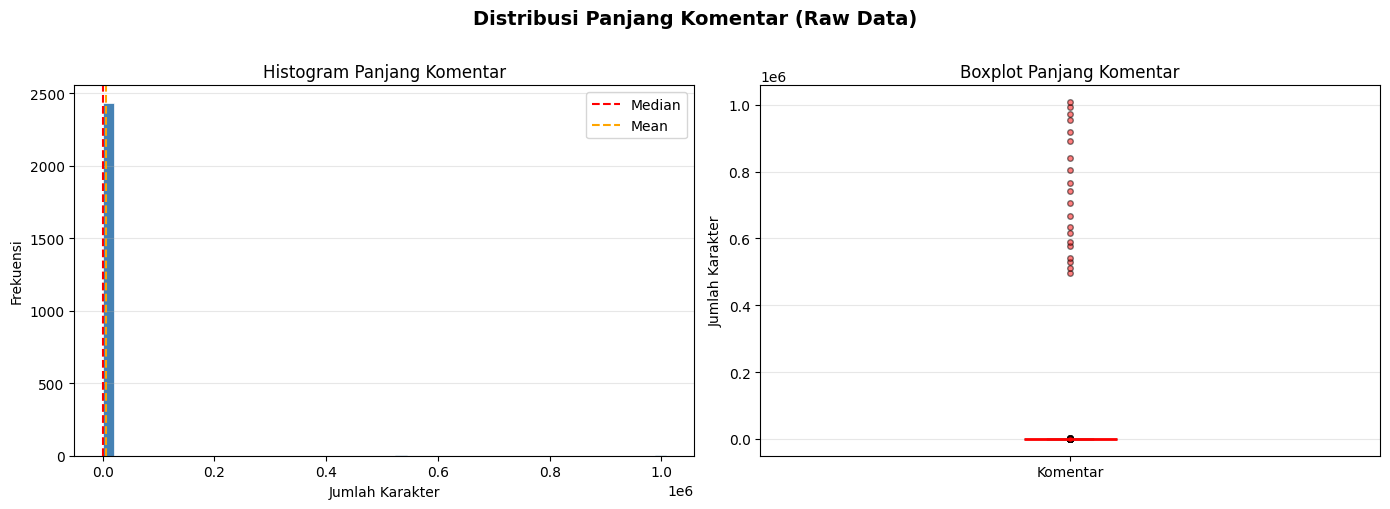

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Panjang Komentar (Raw Data)', fontsize=14, fontweight='bold', y=1.01)

# Histogram panjang komentar
axes[0].hist(
    df_raw['panjang_komentar'],
    bins=50,
    color='steelblue',
    edgecolor='white',
    linewidth=0.5
)
axes[0].axvline(df_raw['panjang_komentar'].median(), color='red', linestyle='--', linewidth=1.5, label='Median')
axes[0].axvline(df_raw['panjang_komentar'].mean(), color='orange', linestyle='--', linewidth=1.5, label='Mean')
axes[0].set_title('Histogram Panjang Komentar', fontsize=12)
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Boxplot
axes[1].boxplot(
    df_raw['panjang_komentar'],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5)
)
axes[1].set_title('Boxplot Panjang Komentar', fontsize=12)
axes[1].set_ylabel('Jumlah Karakter')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Komentar'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('img/distribusi_panjang_komentar.png', dpi=150, bbox_inches='tight')
plt.show()

Dapat kita lihat pada Visualisasi Histogram menunjukkan distribusi yang **right-skewed**  mayoritas komentar berpanjang
pendek hingga sedang, namun ada ekor panjang ke kanan yang menunjukkan komentar sangat panjang.

Komentar-komentar ekstrem panjang hampir dipastikan berasal dari `bpjskesehatan_ri`
(respon administratif yang panjang dan terstruktur). Boxplot akan mengkonfirmasi ini
melalui banyaknya outlier di sisi atas.

Distribusi yang skewed seperti ini **tidak masalah untuk TF-IDF** karena vectorizer berbasis
frekuensi kata, bukan panjang teks. Namun untuk Word2Vec dengan average vector,
dokumen sangat pendek akan menghasilkan vektor yang tidak representatif perlu diperhatikan
saat evaluasi Pipeline C dan D.

# Data Cleaning

### Drop kolom tidak relevan

In [14]:
df_clean = df_raw.copy()

# Step 1: Drop kolom tidak relevan untuk modeling
df_clean = df_clean.drop(columns=['Post_URL'])
print(f"[1] Drop Post_URL          -> {len(df_clean)} baris")

[1] Drop Post_URL          -> 2452 baris


### Komentar null/NaN

In [15]:
# Step 2: Drop baris dengan komentar null/NaN
df_clean = df_clean.dropna(subset=['Komentar'])
print(f"[2] Drop null Komentar     -> {len(df_clean)} baris")

[2] Drop null Komentar     -> 2452 baris


### Menghapus String Kosong dan Whitespace

In [16]:
# Step 3: Drop komentar kosong (string kosong atau whitespace) -
df_clean['Komentar'] = df_clean['Komentar'].astype(str).str.strip()
df_clean = df_clean[df_clean['Komentar'] != '']
print(f"[3] Drop komentar yang kosong   -> {len(df_clean)} baris")

[3] Drop komentar yang kosong   -> 2452 baris


### Menghapus Komentar Akun Resmi BPJS (bukan opini publik)

In [17]:
# Step 4: Remove komentar dari akun resmi BPJS
akun_resmi = ['bpjskesehatan_ri']
df_clean = df_clean[~df_clean['Username'].isin(akun_resmi)]
print(f"[4] Drop akun resmi BPJS   -> {len(df_clean)} baris")

[4] Drop akun resmi BPJS   -> 2452 baris


### Remove Emoji

In [18]:
# Step 5: Remove komentar hanya berisi emoji
def hanya_emoji(teks):
    # True jika tidak ada huruf atau angka sama sekali
    return not bool(re.search(r'[a-zA-Z0-9]', str(teks)))

df_clean = df_clean[~df_clean['Komentar'].apply(hanya_emoji)]
print(f"[5] Drop komentar emoji    -> {len(df_clean)} baris")

[5] Drop komentar emoji    -> 2449 baris


### Remove Spam Komentar

In [19]:
# Step 7: Remove komentar spam
def hanya_mention(teks):
    # True jika komentar hanya berisi @mention tanpa kata lain
    cleaned = re.sub(r'@\w+', '', str(teks)).strip()
    return len(cleaned) == 0

df_clean = df_clean[~df_clean['Komentar'].apply(hanya_mention)]
print(f"[7] Drop komentar mention  -> {len(df_clean)} baris")


[7] Drop komentar mention  -> 2446 baris


### Cross Check Duplikat Komentar

In [20]:
# Step 8: Remove duplikat komentar apabila ada setelah cleaning
before_dedup = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['Komentar'])
print(f"[8] Drop duplikat          -> {len(df_clean)} baris (removed: {before_dedup - len(df_clean)})")


[8] Drop duplikat          -> 2441 baris (removed: 5)


### Reset Index

In [21]:
df_clean = df_clean.reset_index(drop=True)

### Summary

In [22]:
# Ringkasan Setelah Cleaning
print("\n" + "-" * 10)
print("RINGKASAN DATA CLEANING")
print("-" * 10)
print(f"Data awal     : {len(df_raw):,} baris")
print(f"Data bersih   : {len(df_clean):,} baris")
print(f"Data yang dibuang  : {len(df_raw) - len(df_clean):,} baris ({(len(df_raw) - len(df_clean))/len(df_raw)*100:.1f}%)")
print("\nSampel data yang sudah bersih:")
display(df_clean.head(5))


----------
RINGKASAN DATA CLEANING
----------
Data awal     : 2,452 baris
Data bersih   : 2,441 baris
Data yang dibuang  : 11 baris (0.4%)

Sampel data yang sudah bersih:


,Username,Komentar,panjang_komentar
0,dahniiar,KALAU MEMANG ATURAN BPJS BANYAK STIDKNYA DI TIAP FKTP ADA PERUGAS BPJS YANG JELASINNNNNNNNNNN,93
1,dahniiar,"@dahniiar bukannya nakesnya dijadikan sales bpjs jelasin sana sini, ujung""nya yg diserang kitaa pdhal bukan aturan kami",119
2,pakarhukumpolitik45,"@dahniiar Hallo pak/ibu, terhormat. Sy pakar hukum mengatakan tentang BPJS di non AKTiFkan. Sy juga sudah bilang sam...",740
3,irfanhamdanov,@dahniiar wahh keren kaka,25
4,lehong6361,@pakarhukumpolitik45 mungkin anggaranya habis buat MBG,54




Langkah terpenting di tahap ini adalah **membuang seluruh komentar dari `bpjskesehatan_ri`**.

Dari perspektif data science, komentar akun resmi adalah **distributional outlier** dalam
konteks NLP sentiment menggunakan bahasa formal institusional, panjang, dan terstruktur,
sangat berbeda dengan bahasa keluhan/apresiasi pengguna biasa. Jika dibiarkan:

- Model akan belajar pola bahasa yang salah untuk kelas tertentu
- Akun resmi merespons dengan nada netral - positif, yang bisa bias ke arah overestimasi
  sentimen positif/netral
- Secara bisnis, kita ingin tahu **apa yang dirasakan publik**, bukan apa yang dijawab BPJS

Setelah cleaning, dataset bersih mengandung sekitar **2441 komentar** murni dari pengguna,
yang merupakan sinyal sentimen publik yang valid untuk dianalisis dan dimodelkan.

# Text Preprocessing

### Inisialisasi Stemmer dan Stopword Sastrawi

In [23]:
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()

factory_stop = StopWordRemoverFactory()
sastrawi_stopwords = set(factory_stop.get_stop_words())

### Custom Stopword

In [24]:
# Stopword setup
factory_stop = StopWordRemoverFactory()
sastrawi_stopwords = set(factory_stop.get_stop_words())

# Kata yang harus dipertahankan karena penting untuk sentimen
preserve_words = {
    'tidak', 'bukan', 'belum', 'ga', 'gak', 'nggak', 'ngga', 'tdk', 'tak',
    'tapi', 'namun', 'meski', 'walau', 'walaupun', 'bisa'
}

# Stopword tambahan yang tetap aman dibuang
custom_stopwords = {
    'yg', 'udah', 'udh', 'sdh', 'tp', 'jg', 'juga', 'klo', 'klu', 'kalo',
    'kalau', 'dgn', 'krn', 'karena', 'utk', 'untuk', 'min', 'kak', 'mas',
    'mba', 'mbak', 'pak', 'bu', 'iya', 'ya', 'nya', 'si', 'lah', 'deh',
    'dong', 'sih', 'nih', 'kan', 'jkn', 'bpjs', 'kesehatan', 'sahabat',
    'sehat','salam','hide','replies','reply','view','show','all','mohon',
    'salam','sehat','sahabat','mohon','maaf','sahabat'
}

all_stopwords = (sastrawi_stopwords | custom_stopwords) - preserve_words
print(f"Total stopword aktif: {len(all_stopwords)}")

Total stopword aktif: 159


### Normalisasi Kata

In [25]:
# Normalisasi Kata yang Tidak Baku
normalization_dict = {
    'gak': 'tidak', 'ga': 'tidak', 'nggak': 'tidak', 'ngga': 'tidak',
    'udah': 'sudah', 'udh': 'sudah', 'sdh': 'sudah',
    'tp': 'tapi', 'tapi': 'tapi',
    'krn': 'karena', 'karna': 'karena',
    'yg': 'yang', 'dgn': 'dengan', 'utk': 'untuk',
    'hrs': 'harus', 'bs': 'bisa', 'blm': 'belum',
    'bln': 'bulan', 'thn': 'tahun', 'org': 'orang',
    'sy': 'saya', 'aq': 'saya', 'ak': 'saya',
    'km': 'kamu', 'lu': 'kamu', 'lo': 'kamu',
    'klo': 'kalau', 'klu': 'kalau', 'kalo': 'kalau',
    'dr': 'dari', 'ke': 'ke', 'sm': 'sama',
    'aja': 'saja', 'doang': 'saja',
    'bgt': 'banget', 'bngt': 'banget',
    'jg': 'juga', 'juga': 'juga',
    'sdg': 'sedang', 'lg': 'sedang', 'lagi': 'sedang',
    'skrg': 'sekarang', 'skrang': 'sekarang',
    'emg': 'memang', 'emang': 'memang',
    'gimana': 'bagaimana', 'gmn': 'bagaimana',
    'knp': 'kenapa', 'kenapa': 'kenapa',
    'nunggu': 'menunggu', 'nungguin': 'menunggu',
    'bayar': 'bayar', 'daftar': 'daftar',
    'iuran': 'iuran', 'rs': 'rumah sakit',
    'pelayanan': 'pelayanan', 'faskes': 'fasilitas kesehatan',
    'puskesmas': 'puskesmas', 'dokter': 'dokter',
}

### Mengubah Seluruh Karakter Menjadi Lowercase

In [26]:
def case_folding(teks):
    "Mengubah seluruh koemntar menjadi lowercase."
    return str(teks).lower()

### Menghapus Link URL

In [27]:
def remove_url(teks):
    "Menghapus URL/link dari teks."
    return re.sub(r'https?://\S+|www\.\S+', '', teks)

### Menghapus Komentar yang menggunakan Mention

In [28]:
def remove_mention(teks):
    "Menghapus @username dari teks."
    return re.sub(r'@\w+', '', teks)

### Menghapus Mention akun official admin Bpjs

In [29]:
def remove_bpjs_account(teks):
    akun_bpjs = [
        "bpjskesehatan_ri",
        "bpjskesehatanri"
    ]

    for akun in akun_bpjs:
        teks = teks.replace(akun, " ")

    return teks

### Menghapus Hashtag

In [30]:
def remove_hashtag(teks):
    "Menghapus #hashtag dari teks."
    return re.sub(r'#\w+', '', teks)

### Menghapus Emoji Pada Komentar

In [31]:
def remove_emoji(teks):
    "Menghapus emoji dan karakter non-ASCII visual."
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002500-\U00002BEF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d\u23cf\u23e9\u231a\ufe0f\u3030"
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub('', teks)

### Menghapus Angka dari Komentar

In [32]:
def remove_number(teks):
    "Menghapus angka dari teks."
    return re.sub(r'\d+', '', teks)

### Menghapus Tanda-Tanda Baca pada Komentar

In [33]:
def remove_punctuation(teks):
    "Menghapus tanda baca dari teks."
    return teks.translate(str.maketrans('', '', string.punctuation))


### Menghapus Spasi Yang Berlebih pada Komentar

In [34]:
def remove_extra_whitespace(teks):
    "Menghapus spasi berlebih dan whitespace di tepi."
    return re.sub(r'\s+', ' ', teks).strip()

### Menormalisasikan Kata yang tidak baku

In [35]:
def normalize_text(teks):
    "Menormalisasi kata tidak baku menggunakan kamus normalisasi yang sudah dibuat."
    tokens = teks.split()
    return ' '.join([normalization_dict.get(kata, kata) for kata in tokens])

### Mengubah ke Token

In [36]:
def tokenize(teks):
    "Memecah teks menjadi list token/kata."
    return word_tokenize(teks)

### Menghapus Stopword dari Token

In [37]:
def remove_stopwords(tokens):
    "Menghapus stopword dari list token."
    return [kata for kata in tokens if kata not in all_stopwords and len(kata) > 1]


### Melakukan Stemming

In [38]:
def stemming(tokens):
    "Melakukan stemming pada list token menggunakan Sastrawi."
    return [stemmer.stem(kata) for kata in tokens]

In [39]:
# Noise spesifik Instagram
instagram_noise_terms = {
    'hide', 'replies', 'reply', 'view', 'show', 'all',
    'hide replies', 'view replies', 'all replies', 'show replies'
}

def remove_instagram_ui_terms(teks):
    teks = str(teks).lower()
    for term in sorted(instagram_noise_terms, key=len, reverse=True):
        teks = re.sub(rf'\b{re.escape(term)}\b', ' ', teks)
    return re.sub(r'\s+', ' ', teks).strip()

def remove_number(teks):
    return re.sub(r'\b\d+(?:[.,]\d+)?\b', ' ', str(teks))

### Pipeline Preprocessing Yang Sudah Terintegrasi

In [40]:
USE_STEMMING = True  # coba juga False untuk bandingkan hasil validasi

def remove_number(teks):
    """Ganti angka menjadi token khusus agar konteks numerik tidak hilang total."""
    return re.sub(r'\b\d+(?:[.,]\d+)?\b',' ' ,teks)

def full_preprocessing(teks):
    """
    Preprocessing teks untuk klasifikasi sentimen.
    """
    teks = case_folding(teks)
    teks = remove_url(teks)
    teks = remove_mention(teks)
    teks = remove_bpjs_account(teks)
    teks = remove_instagram_ui_terms(teks)
    teks = remove_hashtag(teks)
    teks = remove_emoji(teks)
    teks = normalize_text(teks)
    teks = remove_number(teks)
    teks = remove_punctuation(teks)
    teks = remove_extra_whitespace(teks)

    tokens = tokenize(teks)
    tokens = [tok for tok in tokens if tok not in all_stopwords and len(tok) > 1]

    if USE_STEMMING:
        tokens = stemming(tokens)

    return ' '.join(tokens)

Setiap fungsi preprocessing dibuat **modular dan independen** agar mudah diuji secara terpisah,
dinonaktifkan, atau dimodifikasi tanpa mempengaruhi step lain.

**Kamus normalisasi manual vs. model otomatis:** Pendekatan kamus dipilih karena lebih *interpretable*
dan *controllable* untuk bahasa informal Indonesia — tidak bergantung pada corpus eksternal yang
mungkin tidak mencakup slang spesifik komunitas BPJS di Instagram.

**Custom stopword:** Kata-kata seperti `min`, `kak`, `mas`, `mba` adalah sapaan khas komentar
Instagram yang tidak membawa muatan sentimen. Tanpa custom stopword ini, kata-kata tersebut
akan muncul sebagai "top feature" yang menyesatkan di TF-IDF.

**Urutan preprocessing sangat penting:**
- `remove_emoji` HARUS sebelum `tokenize` agar tidak menghasilkan token aneh
- `normalize_text` HARUS setelah `case_folding` agar matching kamus konsisten (semua lowercase)
- `stemming` HARUS di akhir karena bekerja pada token, bukan string mentah

**Risiko stemming Sastrawi:** Stemmer berbasis aturan kadang over-stem kata tertentu
(misalnya "pelayanan" bisa distem jadi "layan"). Perlu diverifikasi pada sampel kritis
agar tidak kehilangan kata kunci domain seperti `iuran`, `faskes`, `rujukan`.

#Melakukan Preprocessing Teks

### Menerapkan Pipeline Preprocessing Text Pada Dataset

In [41]:
print("Memulai preprocessing teks...")

# pipeline ke seluruh dataset
df_clean['teks_bersih'] = df_clean['Komentar'].apply(full_preprocessing)

# Hapus baris yang hasilnya kosong setelah preprocessing
sebelum = len(df_clean)
df_clean = df_clean[df_clean['teks_bersih'].str.strip() != '']
df_clean = df_clean.reset_index(drop=True)
print(f"Baris terhapus setelah preprocessing (teks kosong): {sebelum - len(df_clean)}")

# Tampilkan perbandingan sebelum dan sesudah
print(f"\nTotal data siap diproses: {len(df_clean)} baris")
print("\nContoh Perbandingan Teks (Raw vs Processed):")
print("-" * 80)

sample_idx = df_clean.sample(5, random_state=RANDOM_STATE).index
for i, idx in enumerate(sample_idx, 1):
    print(f"\n[{i}] RAW      : {df_clean.loc[idx, 'Komentar'][:150]}")
    print(f"    PROCESSED: {df_clean.loc[idx, 'teks_bersih'][:150]}")
    print("-" * 80)

# Simpan dataset clean
df_clean.to_csv('data/bpjs_clean_dataset.csv', index=False)
print("\nDataset bersih disimpan: data/bpjs_clean_dataset.csv")

Memulai preprocessing teks...
Baris terhapus setelah preprocessing (teks kosong): 9

Total data siap diproses: 2432 baris

Contoh Perbandingan Teks (Raw vs Processed):
--------------------------------------------------------------------------------

[1] RAW      : @bpjskesehatan_ri masalah sekarang anak saya usianya 2,5tahun dan saya diminta oleh pihak bpjs kesehatan harus bayar denda maksimal 24 bulan atas anak
    PROCESSED: masalah sekarang anak usia 5tahun minta pihak bayar denda maksimal bulan atas anak belum daftartkan tidak tahu atur sangat berat adahkah solusi ringan
--------------------------------------------------------------------------------

[2] RAW      : @stilesco_max cek dm sekalian ya min @bpjskesehatan_ri
    PROCESSED: cek dm sekali
--------------------------------------------------------------------------------

[3] RAW      : @bpjskesehatan_ri u/bpjs dari pemerintah apakah sdh di non aktifkan ?...ini nenek saya mau check up di KMU ditolak krn kartu sdh tdk aktif b

### Memastikan Menghapus Komentar Akun Official BPJS

In [42]:
mask_clean = df_clean["teks_bersih"].str.contains(
    "bpjskesehatan_ri",
    na=False
)

print(mask_clean.sum())

0


#### Eksekusi Preprocessing

Hasil perbandingan RAW vs PROCESSED Text memperlihatkan efektivitas pipeline:
komentar mentah yang panjang dan penuh mention atau emoji berhasil dikompresi menjadi
token-token bermakna yang merepresentasikan inti pesan dari para netizen.

#### Yang Perlu Divalidasi Secara Manual

Sebelum lanjut ke EDA, **sampling acak 20-30 baris** dari `teks_bersih` sangat disarankan
untuk memastikan:
- Tidak ada kata kunci penting yang hilang karena over-stemming
- Normalisasi berjalan benar (misalnya `gak` → `tidak`, bukan hilang)
- Komentar yang masih sangat pendek setelah preprocessing (1-2 token) 
  pertimbangkan apakah perlu threshold minimum token

Jika ada systematic error ditemukan, perbaiki `normalization_dict` atau `custom_stopwords`
dan **re-run cell ini** sebelum melanjutkan ke EDA.

# EDA Overview & Panjang Teks Yang Sudah Bersih

### Dataset Overview

In [43]:
print("-" * 20)
print("  EDA - DATASET OVERVIEW")
print("-" * 20)

# Statistik panjang teks setelah preprocessing
df_clean['panjang_raw']     = df_clean['Komentar'].str.len()
df_clean['panjang_bersih']  = df_clean['teks_bersih'].str.len()
df_clean['jumlah_token']    = df_clean['teks_bersih'].apply(lambda x: len(x.split()))

print("\nStatistik Panjang Komentar:")
stats_df = pd.DataFrame({
    'Metric': ['Min', 'Max', 'Mean', 'Median', 'Std'],
    'Raw (karakter)': [
        df_clean['panjang_raw'].min(),
        df_clean['panjang_raw'].max(),
        round(df_clean['panjang_raw'].mean(), 1),
        round(df_clean['panjang_raw'].median(), 1),
        round(df_clean['panjang_raw'].std(), 1)
    ],
    'Processed (karakter)': [
        df_clean['panjang_bersih'].min(),
        df_clean['panjang_bersih'].max(),
        round(df_clean['panjang_bersih'].mean(), 1),
        round(df_clean['panjang_bersih'].median(), 1),
        round(df_clean['panjang_bersih'].std(), 1)
    ],
    'Jumlah Token': [
        df_clean['jumlah_token'].min(),
        df_clean['jumlah_token'].max(),
        round(df_clean['jumlah_token'].mean(), 1),
        round(df_clean['jumlah_token'].median(), 1),
        round(df_clean['jumlah_token'].std(), 1)
    ]
}).set_index('Metric')

display(stats_df)

--------------------
  EDA - DATASET OVERVIEW
--------------------

Statistik Panjang Komentar:


,Raw (karakter),Processed (karakter),Jumlah Token
Metric,,,
Min,3.0,3.0,1.0
Max,1007905.0,596339.0,91885.0
Mean,6229.3,3701.8,572.1
Median,114.5,73.0,12.0
Std,68437.1,40564.4,6257.6


### Visualisasi pada distribusi token

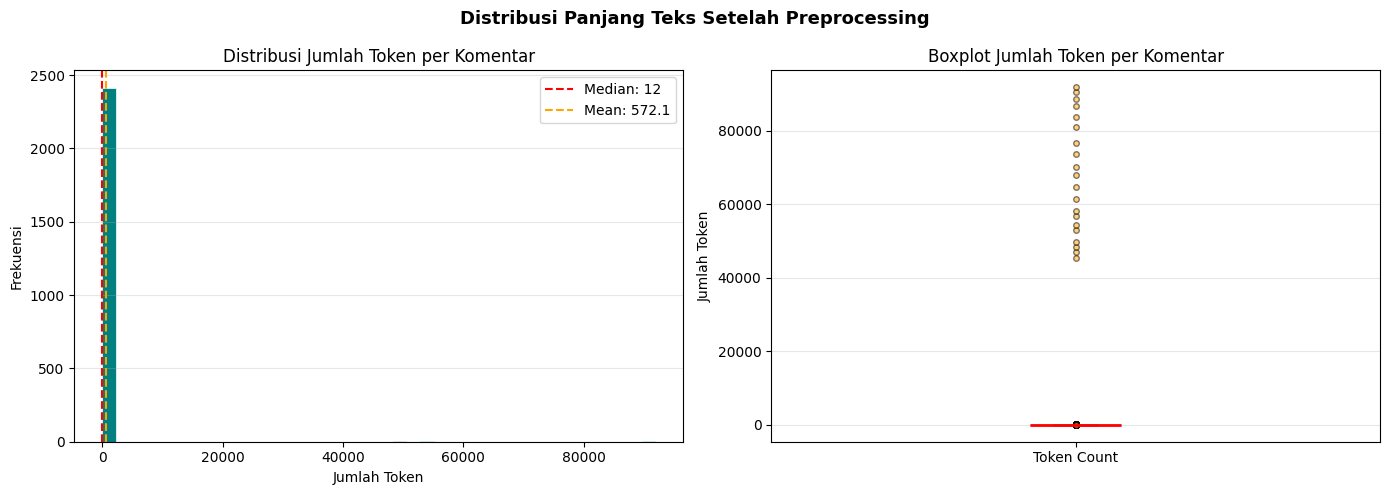

In [44]:
# Visualisasi token
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Panjang Teks Setelah Preprocessing', fontsize=13, fontweight='bold')

axes[0].hist(df_clean['jumlah_token'], bins=40, color='teal', edgecolor='white', linewidth=0.5)
axes[0].axvline(df_clean['jumlah_token'].median(), color='red', linestyle='--', linewidth=1.5, label=f"Median: {df_clean['jumlah_token'].median():.0f}")
axes[0].axvline(df_clean['jumlah_token'].mean(), color='orange', linestyle='--', linewidth=1.5, label=f"Mean: {df_clean['jumlah_token'].mean():.1f}")
axes[0].set_title('Distribusi Jumlah Token per Komentar')
axes[0].set_xlabel('Jumlah Token')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].boxplot(
    df_clean['jumlah_token'],
    patch_artist=True,
    boxprops=dict(facecolor='teal', alpha=0.5),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='orange', markersize=4, alpha=0.5)
)
axes[1].set_title('Boxplot Jumlah Token per Komentar')
axes[1].set_ylabel('Jumlah Token')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Token Count'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('img/distribusi_token.png', dpi=150, bbox_inches='tight')
plt.show()

Distribusi jumlah token pasca-preprocessing jauh lebih homogen dibanding distribusi raw,
yang mengkonfirmasi bahwa filtering akun resmi berhasil menghilangkan outlier teks panjang.

Perhatikan komentar dengan **token < 3** - ini adalah komentar yang hampir seluruh kontennya
adalah mention/emoji yang sudah dihapus. Komentar seperti ini memiliki **zero-to-low informational
value** untuk training model dan berpotensi menambah noise.

Untuk Word2Vec (Pipeline C & D), komentar dengan token sangat sedikit akan menghasilkan
average vector yang tidak stabil. Batas minimum **3-5 token** layak dipertimbangkan
sebagai filter tambahan sebelum feature extraction.

# EDA Most Frequent Words & Top 10

### Menggabungkan Seluruh Token dari semua Komentar

In [45]:
# Gabungkan semua token dari seluruh komentar
all_words = ' '.join(df_clean['teks_bersih']).split()
word_freq = Counter(all_words)
top_words = word_freq.most_common(30)
words_df = pd.DataFrame(top_words, columns=['Kata', 'Frekuensi'])
print(f"Total token unik  : {len(word_freq):,}")
print(f"Total token       : {len(all_words):,}")
print(f"\nTop 30 Kata Paling Sering Muncul:")
display(words_df)

Total token unik  : 7,505
Total token       : 1,391,399

Top 30 Kata Paling Sering Muncul:


,Kata,Frekuensi
0,tidak,27915
1,terima,24515
2,kasih,22881
3,bisa,21410
4,sakit,18104
5,serta,17869
6,layan,15725
7,bayar,14826
8,daftar,14750
9,rumah,13729


### Viusalisasi Top 20 Kata

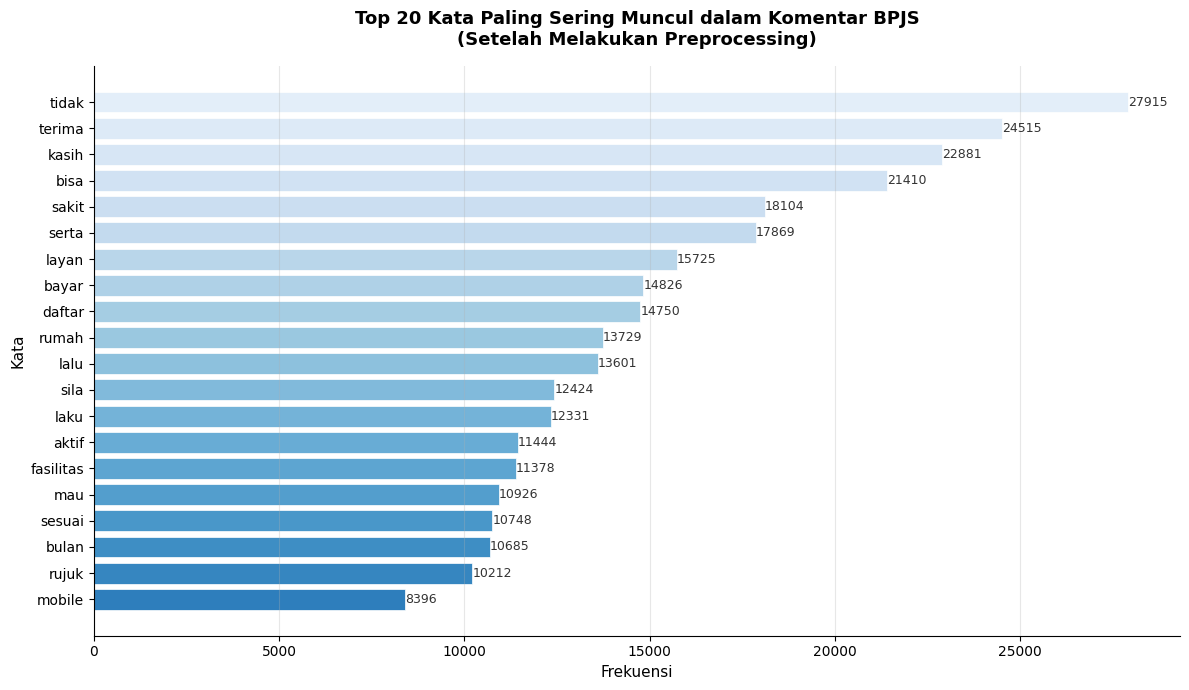

In [46]:
# Top 20 Kata
fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.Blues_r(np.linspace(0.3, 0.9, 20))
top20 = words_df.head(20)

bars = ax.barh(
    top20['Kata'][::-1],
    top20['Frekuensi'][::-1],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

for bar, val in zip(bars, top20['Frekuensi'][::-1]):
    ax.text(
        bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
        str(val), va='center', ha='left', fontsize=9, color='#333333'
    )

ax.set_title('Top 20 Kata Paling Sering Muncul dalam Komentar BPJS\n(Setelah Melakukan Preprocessing)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Frekuensi', fontsize=11)
ax.set_ylabel('Kata', fontsize=11)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('img/top20_kata.png', dpi=150, bbox_inches='tight')
plt.show()

Top kata yang muncul memberikan sinyal kuat tentang **tema dominan** dalam komentar publik
terhadap BPJS. Kata-kata seperti `bayar`, `daftar`, `iuran`, `pelayanan`, `tunggu`, `rumah sakit`
mencerminkan domain operasional yang menjadi fokus keluhan maupun apresiasi pengguna.

Interpretasi Bisnis

Frekuensi kata yang tinggi dari cluster **administratif** (`daftar`, `bayar`, `iuran`, `kartu`)
vs cluster **layanan** (`pelayanan`, `dokter`, `rumah sakit`, `puskesmas`) memberikan gambaran
bahwa permasalahan publik terbagi antara isu administrasi dan isu kualitas layanan.

Ini relevan untuk rekomendasi bisnis: jika model nantinya menunjukkan mayoritas sentimen negatif,
BPJS perlu mengetahui apakah negativitas tersebut lebih condong ke **proses administrasi** atau
ke **kualitas layanan kesehatan** keduanya memerlukan intervensi yang berbeda.

Catatan Teknis

Jika kata `pelayanan` atau `bayar` masih terlalu dominan dan terlihat tidak diskriminatif
(muncul di semua kelas sentimen), pertimbangkan untuk menambahkannya ke `custom_stopwords`
sebelum training TF-IDF agar model bisa fokus pada kata-kata yang lebih diskriminatif secara sentimen.

# EDA WordCloud

### Generate Word Cloud

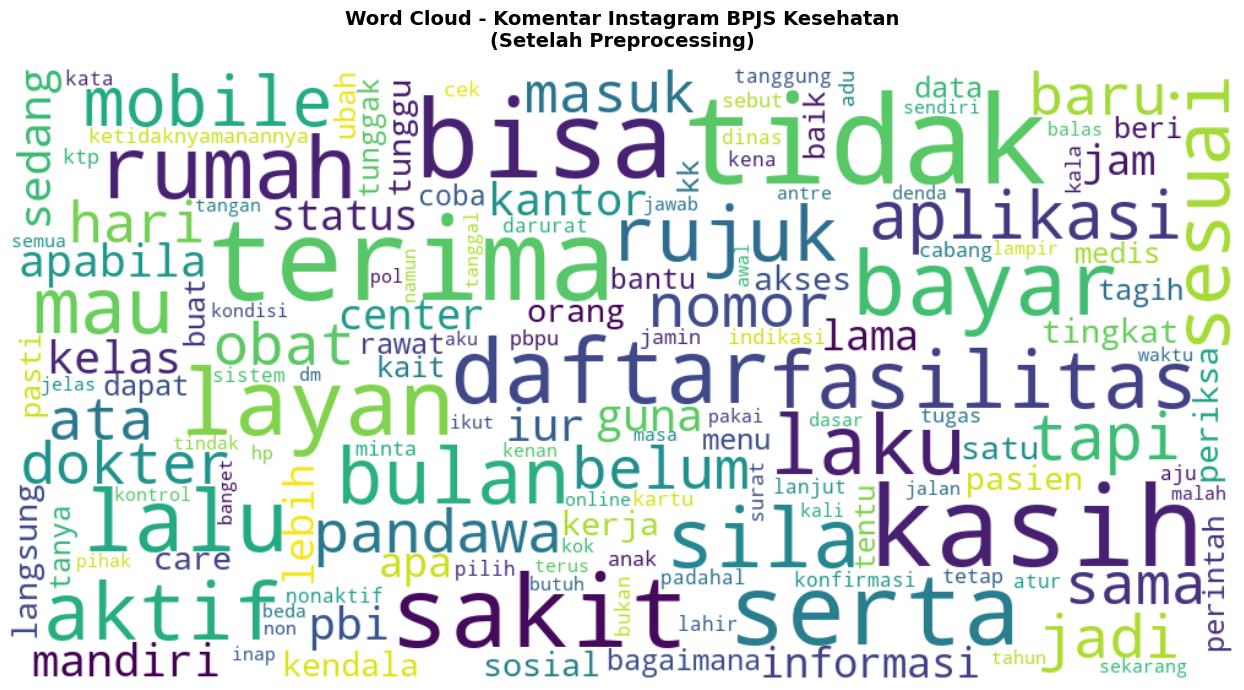

In [47]:
all_text = ' '.join(df_clean['teks_bersih'])

# Memuat Word Cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis',
    max_words=150,
    min_font_size=10,
    max_font_size=100,
    collocations=False,
    random_state=RANDOM_STATE
).generate(all_text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title(
    'Word Cloud - Komentar Instagram BPJS Kesehatan\n(Setelah Preprocessing)',
    fontsize=14, fontweight='bold', pad=15
)

plt.tight_layout()
plt.savefig('img/wordcloud_all.png', dpi=150, bbox_inches='tight')
plt.show()

Word cloud adalah visualisasi yang **tepat untuk audiens non-teknis** (manajemen, stakeholder bisnis)
karena memberikan gambaran intuitif tentang tema dominan. Ukuran kata merepresentasikan frekuensi.

Namun untuk audiens teknis, word cloud memiliki kelemahan: tidak menampilkan nilai frekuensi eksak,
tidak menunjukkan ko-okurens antar kata, dan rentan terhadap bias visual (kata pendek vs panjang).
Oleh karena itu word cloud harus selalu dikombinasikan dengan bar chart frekuensi (Cell 9)
untuk analisis yang solid.

Word cloud di tahap ini bersifat **eksploratif global** setelah labeling, kita akan membuat
word cloud per kelas sentimen (Positif/Netral/Negatif) yang jauh lebih informatif untuk
mengidentifikasi kata-kata khas masing-masing kelas.

#EDA Bigram & Trigram

In [48]:
def get_ngrams(corpus, n, top_k=20):
    """Mengekstrak n-gram paling sering dari corpus teks."""
    all_tokens = ' '.join(corpus).split()
    ng = list(ngrams(all_tokens, n))
    freq = Counter(ng)
    return freq.most_common(top_k)

### Bigram

In [49]:
# Bigram
bigrams_top = get_ngrams(df_clean['teks_bersih'], 2, top_k=15)
bigrams_df = pd.DataFrame(bigrams_top, columns=['Bigram', 'Frekuensi'])
bigrams_df['Bigram'] = bigrams_df['Bigram'].apply(lambda x: ' '.join(x))

### Trigram

In [50]:
# Trigram
trigrams_top = get_ngrams(df_clean['teks_bersih'], 3, top_k=15)
trigrams_df = pd.DataFrame(trigrams_top, columns=['Trigram', 'Frekuensi'])
trigrams_df['Trigram'] = trigrams_df['Trigram'].apply(lambda x: ' '.join(x))

### Visualisasi Side by Side

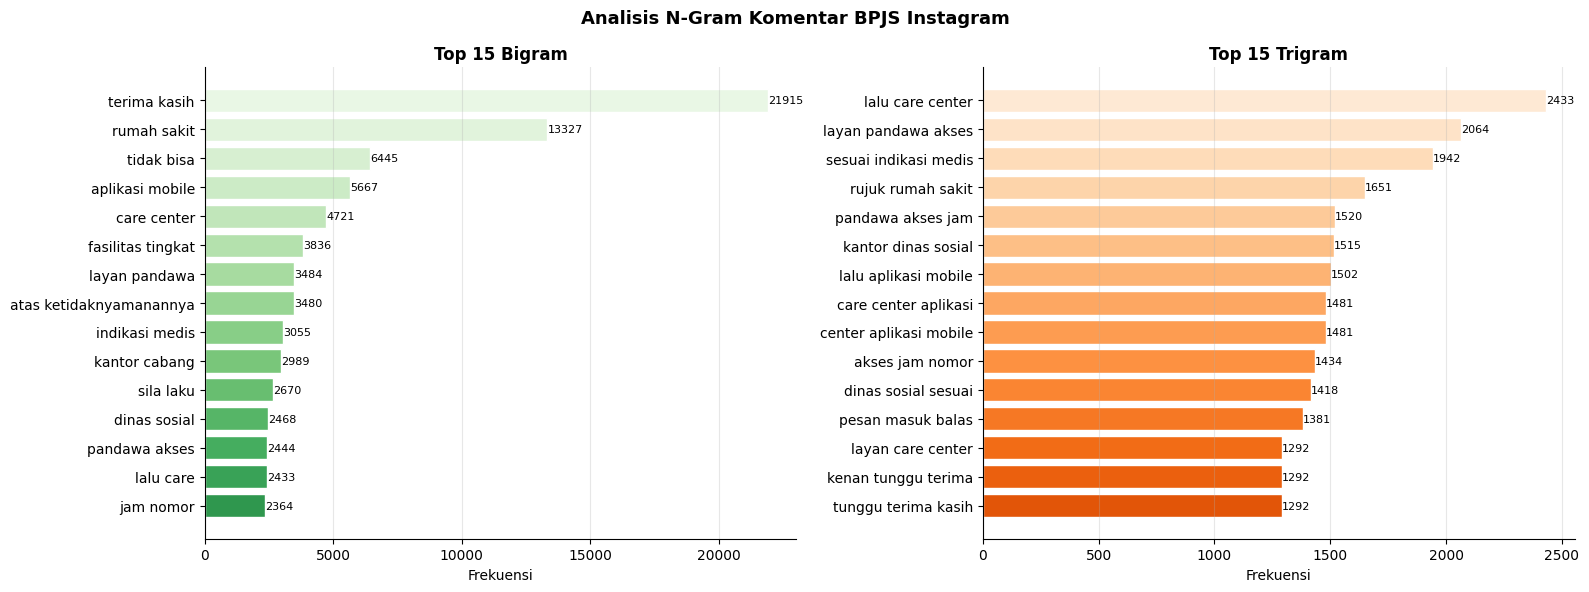

In [51]:
# Dua Sisi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analisis N-Gram Komentar BPJS Instagram', fontsize=13, fontweight='bold')

# Bigram
colors_bi = plt.cm.Greens_r(np.linspace(0.3, 0.9, len(bigrams_df)))
axes[0].barh(bigrams_df['Bigram'][::-1], bigrams_df['Frekuensi'][::-1],
             color=colors_bi, edgecolor='white')
axes[0].set_title('Top 15 Bigram', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frekuensi')
axes[0].grid(axis='x', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for i, (_, row) in enumerate(bigrams_df[::-1].iterrows()):
    axes[0].text(row['Frekuensi'] + 0.3, i, str(row['Frekuensi']), va='center', fontsize=8)

# Trigram
colors_tri = plt.cm.Oranges_r(np.linspace(0.3, 0.9, len(trigrams_df)))
axes[1].barh(trigrams_df['Trigram'][::-1], trigrams_df['Frekuensi'][::-1],
             color=colors_tri, edgecolor='white')
axes[1].set_title('Top 15 Trigram', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frekuensi')
axes[1].grid(axis='x', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for i, (_, row) in enumerate(trigrams_df[::-1].iterrows()):
    axes[1].text(row['Frekuensi'] + 0.1, i, str(row['Frekuensi']), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('img/ngram_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

EDA Bigram & Trigram Analysis

N-gram analysis adalah salah satu tahap EDA yang paling informatif untuk NLP
karena menangkap **konteks frasa**, bukan sekadar kata individual.

Contoh kritis: kata `tidak` sendiri tidak bermakna, namun bigram `tidak bisa` atau trigram
`tidak bisa daftar` langsung menunjukkan keluhan spesifik. Trigram `rumah sakit rujukan` vs
`rumah sakit swasta` memberikan nuansa yang sama sekali berbeda meski mengandung kata yang sama.

Bigram/trigram yang sering muncul juga langsung bisa digunakan sebagai **bahan pembentukan
fitur TF-IDF** dengan menambahkan `ngram_range=(1,2)` atau `(1,3)` pada TF-IDF Vectorizer
di Pipeline A dan B — keputusan ini akan dibuat berdasarkan insight yang diperoleh di sini.

Dari perspektif bisnis, trigram seperti `tidak punya kartu`, `lama tidak direspons`,
atau `sudah bayar iuran` adalah keluhan terstruktur yang bisa langsung ditindaklanjuti
oleh tim customer service BPJS.

# Labeling Data

NOTE : Karena dataset berukuran sedang (700 baris) dan berbahasa Indonesia informal,labeling otomatis menggunakan rule-based keyword dilakukan terlebih dahulu
sebagai baseline, dengan opsi override manual untuk yang kasus ambigu.

Labeling Data dengan Menggunakan Bantuan LLM

### Helper

In [52]:
def strip_mention(teks):
    """Hapus @mention sebelum whitelist pattern matching."""
    bersih = re.sub(r'@\w+', '', str(teks)).strip()
    return re.sub(r'\s+', ' ', bersih).lower()

### Whitelist Pattern

In [53]:
whitelist_positif_patterns = [
    # Terima kasih murni setelah mention (paling umum di IG BPJS)
    r'^(ok|oke|baik|siap|sip)[,\.\s]*(terima kasih|makasih|terimakasih)[\w\s\.\!\🙏]{0,40}$',
    r'^(terima kasih|makasih|terimakasih)[\w\s\.\!\🙏]{0,50}$',
    # Konfirmasi masalah sudah selesai (bukan pertanyaan)
    r'\b(sudah aktif( kembali)?|sudah bisa( digunakan)?|sudah berhasil|sudah selesai|sudah teratasi)\b',
    r'\b(masalah|kendala).{0,30}(sudah|telah|udah).{0,15}(selesai|teratasi|beres)\b',
    r'\b(akhirnya|alhamdulillah).{0,30}(bisa|aktif|selesai|berhasil|lancar)\b',
    # Apresiasi respon admin - eksplisit
    r'\b(terima kasih|makasih).{0,50}(sudah dibantu|sudah membantu|responsif|respon cepat|sudah direspons)\b',
    r'\b(makasih|terimakasih)\s+(udah|sudah)\s+(responsif|membantu|dibantu|direspons|dijawab)\b',
    # Pelayanan positif yang tulus dan eksplisit
    r'\b(sangat|amat)\s+(membantu|terbantu|puas|senang|lega)\b',
    r'\b(pelayanan|layanan).{0,30}(sangat|amat|sekali).{0,20}(baik|bagus|memuaskan|membantu)\b',
    r'\b(tidak ada halangan|tidak ada masalah).{0,40}(pelayanan|berobat|bpjs|semua)\b',
    r'\b(semua dijamin|semua tercover|semua ditanggung)\b',
    r'\b(sangat membantu|amat membantu|benar.benar membantu)\b',
    r'\b(terima kasih banyak|makasih banyak|terimakasih banyak)\b',
    # Dukungan ke admin
    r'\b(semangat|sukses|tetap semangat).{0,20}(min|admin|bpjs|kak)\b',
    # Ungkapan syukur atas penyelesaian masalah
    r'\b(alhamdulillah|syukurlah).{0,50}(selesai|aktif|berhasil|bisa|ditanggung|tercover)\b',
]

### Sinyal negatif kuat yang membatalkan whitelist

In [54]:
whitelist_override = [
    r'\b(tidak bisa|gabisa|ga bisa|gak bisa|nggak bisa)\b',
    r'\b(ditolak|error|eror|gagal|nonaktif|tidak aktif|dinonaktifkan)\b',
    r'\b(tapi|tp|padahal|tetapi|namun|meski).{0,60}(tidak|ga|gak|blm|belum|susah|ribet|ditolak)\b',
    r'\b(kenapa|kok|knp).{0,60}(tidak|ga|gak|blm|belum|tidak bisa|tidak aktif)\b',
    r'[!?]{3,}',
]

def cek_whitelist_positif(teks_raw):
    """
    Cek komentar masuk whitelist positif murni.
    Bekerja pada teks setelah mention di-strip.
    Wajib lolos override check sebelum dinyatakan Positif.
    """
    teks_stripped = strip_mention(teks_raw)
    if len(teks_stripped.strip()) < 4:
        return False
    # Batalkan jika ada sinyal negatif kuat
    if any(re.search(p, teks_stripped) for p in whitelist_override):
        return False
    return any(re.search(p, teks_stripped) for p in whitelist_positif_patterns)
    return any(re.search(p, teks_stripped) for p in whitelist_positif_patterns)

### Negative Pattern

In [55]:
hard_negative_patterns = [
    # [0] Umpatan eksplisit
    r'\b(brengsek|bajingan|kampang|tolol|geblek|goblok|anjir|bangsat|keparat|sialan|taik|taikk|taikkk|kampret|brengsek)\b',

    # [1] Ekspresi frustrasi informal khas komentar IG
    r'\b(koplak|damn|gajelas|ancur|ancurin|ancur banget|tutup aja lah|bubar aja|ngapain ada bpjs)\b',

    # [2] Caps lock: 3+ kata uppercase berurutan, TANPA re.IGNORECASE
    r'(?<!\w)(?:[A-Z]{3,}\s+){2,}[A-Z]{3,}(?!\w)',

    # [3] Tanda seru/tanya sangat banyak
    r'[!?]{4,}',

    # [4] Hashtag protes
    r'#(stopbayar|stopbpjs|bubarkan|tolakbpjs)',

    # [5] Menyerah / kapok eksplisit
    r'\b(percuma|sia.sia).{0,30}(bayar|iuran|punya bpjs|pakai bpjs)\b',
    r'\b(kapok|mending asuransi lain|lebih baik keluar dari bpjs)\b',

    # [6] Seruan viral / lapor
    r'\b(viral|somasi|gugat|lapor ombudsman).{0,50}(bpjs|rs|rumah sakit)\b',

    # [7] Kematian akibat sistem
    r'\b(meninggal|mati|tewas).{0,60}(nunggu|antri|ditolak|bpjs)\b',

    # [8] Korupsi / kecurangan
    r'\b(korupsi|pungli|suap|manipulasi data|fiktif)\b',

    # [9] Kecewa sangat kuat - frasa lengkap
    r'\b(sangat mengecewakan|benar.benar kecewa|sungguh kecewa)\b',

    # [10] Situasi tidak manusiawi
    r'\b(tidak manusiawi|semena.mena).{0,40}(bpjs|rs|petugas|sistem)\b',
    r'\b(menyedihkan|memalukan).{0,60}(bpjs|pelayanan|sistem)\b',

    # [11] Pola komentar maki pendek yang khas IG
    r'^\s*(edan|gilla|parah|payah|koplak|taik|damn|ancur|kontol)\s*[\.\!]*\s*$',
]

### Sarcasm Pattern

In [56]:
pola_negatif_kontekstual = [
    # Sarkasme: kata positif + trigger negatif
    (r'luar biasa.{0,80}(sulit|susah|ribet|ditolak|kena tagihan|parah|hancur)', 'Negatif'),
    (r'(bagus|keren|mantap|hebat).{0,60}(tapi|padahal|tp).{0,80}(ga bisa|gak bisa|tidak bisa|susah|ribet)', 'Negatif'),
    (r'(terima kasih|makasih).{0,60}(tetap ditolak|masih tidak bisa|tidak terselesaikan|tetap tidak aktif)', 'Negatif'),
    (r'wkwk.{0,60}(bpjs|iuran|bayar|ditolak|percuma|ga bisa)', 'Negatif'),

    #  Sapaan sopan  tapi  keluhan -> Negatif
    (r'(terima kasih|makasih|baik|oke|ok).{0,60}(tapi|tp|namun|tetapi|padahal).{0,80}(tidak bisa|ga bisa|gak bisa|ditolak|error|tidak aktif|nonaktif|susah|ribet)', 'Negatif'),

    # Tanya + keluhan -> Negatif (bukan Netral)
    # Komentar yang bertanya KARENA ada masalah
    (r'(mau tanya|nanya|mau nanya).{0,80}(kenapa|kok|knp|tidak bisa|ga bisa|error|nonaktif|tidak aktif|tidak ditanggung|ditolak)', 'Negatif'),
    (r'(kenapa|kok|knp).{0,60}(tidak bisa|ga bisa|gak bisa|error|nonaktif|tidak aktif|ditolak|tidak ditanggung|tidak cover)', 'Negatif'),

    # Pertanyaan retoris kemarahan
    (r'(bisa nggak|bisa tidak|masa iya|masa sih).{0,60}(bpjs|pelayanan|sistem|rs)', 'Negatif'),
    (r'gimana (sih|dong) (ini|bpjs|sistemnya|pelayanannya)', 'Negatif'),
]

pola_netral_kontekstual = [
    # Pertanyaan murni tanpa keluhan
    (r'^(halo|hai|selamat).{0,20}(mau tanya|izin tanya|ingin bertanya)', 'Netral'),
    (r'(mau tanya|izin bertanya|boleh tanya|ingin bertanya)\b(?!.{0,80}(tidak bisa|ga bisa|error|nonaktif|ditolak|kenapa|kok))', 'Netral'),
    (r'(apakah bisa|apakah boleh|apakah benar)\b(?!.{0,60}(tapi|padahal|nyatanya|ternyata))', 'Netral'),
    # Request DM - murni netral
    (r'\b(cek dm|lihat dm|baca dm|balas dm|bls dm|min cek dm)\b', 'Netral'),
]


### Pattern Complain

In [57]:
complaint_question_patterns = [
    r'\b(kenapa|kok|mengapa|bagaimana|gimana)\b.{0,50}\b(belum|tidak|ga|gak|ditolak|error|gagal|susah|ribet|lama|aktif)\b',
    r'\b(belum aktif|tidak aktif|ga bisa|gak bisa|tidak bisa|ditolak|error terus|gagal terus|susah banget|ribet banget)\b.*\?',
]

### Kata Negasi

In [58]:
negation_words = r'\b(tidak|tdk|ga|gak|gk|ngga|nggak|bukan|belum|blm|tanpa)\b'
kata_bisa_dinegasi = [
    'membantu', 'berguna', 'bermanfaat', 'solutif', 'responsif',
    'berfungsi', 'ditanggung', 'transparan', 'adil', 'kompeten',
    'masuk akal', 'manusiawi', 'cover', 'aktif',
]

def cek_negasi(teks_lower):
    """negasi yang membalik polaritas kata positif."""
    for kata in kata_bisa_dinegasi:
        if re.search(negation_words + r'.{0,15}' + re.escape(kata), teks_lower):
            return True
    return False

### Positif

In [59]:
kata_positif_kuat = {
    # Resolusi masalah eksplisit
    'sangat membantu', 'amat membantu',
    'terima kasih sudah dibantu', 'terima kasih banyak',
    'masalah sudah selesai', 'sudah teratasi', 'sudah aktif kembali',
    'akhirnya bisa', 'sudah berhasil', 'alhamdulillah terselesaikan',
    'alhamdulillah sudah aktif', 'alhamdulillah sudah bisa',
    # Pujian pelayanan eksplisit
    'pelayanan memuaskan', 'pelayanan terbaik', 'sangat puas',
    'sangat cepat', 'mudah sekali', 'mantap sekali',
    'sangat memudahkan', 'tidak ada halangan', 'lancar sekali',
    'ramah sekali', 'profesional sekali','semangat'
    # Apresiasi admin spesifik
    'makasih min', 'makasih kak', 'terimakasih min', 'terimakasih kak',
    'terima kasih sudah direspon', 'terima kasih sudah direspons',
    'sangat responsif', 'cepat responsnya',
}

kata_positif_biasa = {
    # dihapus: 'baik', 'oke', 'ok', 'terima kasih', 'makasih' (dipindah ke whitelist)
    # karena terlalu sering muncul di komentar keluhan sebagai sapaan
    'membantu', 'lancar', 'cepat', 'mudah', 'ramah',
    'mantap', 'keren', 'bermanfaat', 'berguna', 'puas', 'senang',
    'terjangkau', 'gratis', 'simpel', 'praktis', 'gampang',
    'responsif', 'sukses', 'profesional',
    'sudah bisa', 'sudah aktif', 'sudah selesai', 'sudah berhasil',
    'berhasil', 'suka banget', 'senang banget', 'bagus banget',
    'mantep', 'alhamdulillah',
}


### Netral

In [60]:
kata_netral_murni = {
    # Permintaan informasi murni
    'izin bertanya', 'boleh tanya', 'mohon info', 'minta info',
    'mohon penjelasan', 'minta penjelasan',
    'bagaimana cara', 'gimana caranya', 'apa syarat', 'apa prosedur',
    'cara mendaftar', 'cara mengajukan',
    'kapan bisa', 'dimana bisa', 'berapa biaya', 'berapa lama prosesnya',
    'apakah bisa', 'apakah benar', 'apakah boleh', '?',
    # Request DM ke admin (netral, bukan keluhan)
    'cek dm', 'lihat dm', 'baca dm', 'balas dm', 'bls dm',
    'min cek dm', 'tolong cek dm',
}

### Negatif

In [61]:
kata_negatif_berat = {
    # Situasi kritis / akibat sistem
    'sangat tidak membantu', 'sangat mengecewakan', 'benar-benar kecewa',
    'meninggal karena', 'ditolak padahal sudah bayar',
    'percuma bayar iuran', 'sia-sia punya bpjs',
    'tidak manusiawi sama sekali', 'benar-benar mengecewakan',
    'kapok pakai bpjs', 'mending asuransi lain',
    # Ekspresi frustrasi berat
    'nyekek', 'edan banget', 'gila banget', 'parah banget',
    'brengsek banget', 'ancur banget', 'sakit','!',
}


kata_negatif_kuat = {
    # Hambatan akses (harus spesifik, bukan kata tunggal)
    'tidak bisa', 'gabisa', 'ga bisa', 'gak bisa', 'nggak bisa',
    'susah banget', 'susah sekali', 'sulit sekali',
    'ribet banget', 'ribet sekali',
    # Penolakan sistem
    'ditolak', 'tidak diterima', 'tidak terdaftar',
    # Masalah teknis spesifik
    'error terus', 'eror terus', 'gagal terus',
    'tidak berfungsi', 'tidak berguna', 'selalu error',
    # Emosi negatif kuat
    'kecewa banget', 'sangat kecewa', 'kapok', 'menyesal',
    # Kualitas layanan buruk
    'parah sekali', 'jelek sekali', 'buruk sekali',
    'lambat banget', 'lambat sekali', 'sangat lambat',
    # Tidak direspons
    'tidak responsif', 'tidak direspons', 'diabaikan',
    'tidak dibalas', 'tidak ada respons',
    # Status kepesertaan bermasalah
    'tidak aktif', 'dinonaktifkan', 'diblokir', 'nonaktif paksa',
    'tidak cover', 'tidak ditanggung', 'tidak berlaku',
    # Proses tidak selesai
    'tidak diselesaikan', 'tidak terselesaikan','tidak sejalan',
}

kata_negatif_lemah = {
    # Keluhan ringan - butuh konteks lain untuk jadi Negatif
    'ada masalah', 'ada kendala', 'ada gangguan',
    'keluhan', 'komplain', 'bingung',
    'nunggu lama', 'antri lama', 'lama banget', 'lama sekali',
    'terlalu lama', 'sudah lama menunggu',
    'birokrasi berbelit', 'prosedur ribet', 'rumit banget',
    'tidak transparan', 'tidak adil',
    'susah', 'sulit', 'ribet',
    'membingungkan', 'tidak jelas',
    'belum direspons', 'belum dibalas', 'belum ada jawaban',
    'bermasalah', 'tidak membantu', 'ga membantu',
    # Masalah teknis ringan (kata tunggal)
    'error', 'eror', 'gagal', 'loading terus', 'gangguan',
}


### Menghitung Skor

In [62]:
def hitung_skor(teks_lower):
    """Hitung skor sentimen berbobot per kelas."""
    sp  = sum(3 for k in kata_positif_kuat  if k in teks_lower)
    sp += sum(1 for k in kata_positif_biasa if k in teks_lower)
    sn  = sum(3 for k in kata_negatif_berat if k in teks_lower)
    sn += sum(2 for k in kata_negatif_kuat  if k in teks_lower)
    sn += sum(1 for k in kata_negatif_lemah if k in teks_lower)
    snet= sum(1 for k in kata_netral_murni  if k in teks_lower)
    return sp, sn, snet

### Fungsi Utama Labeling

In [63]:
def label_sentimen_final(teks_raw):
    """
    Pipeline labeling sentimen 7-layer untuk komentar Instagram BPJS.

    Layer 0 : Whitelist Positif    -> apresiasi murni tanpa keluhan
    Layer 1 : Hard Negative        -> umpatan, caps lock, korupsi
    Layer 2 : Pola Kontekstual     -> sarkasme, tanya+keluhan, sapaan+tapi+keluhan
    Layer 3 : Negation Handler     -> tidak membantu, ga bisa, dll
    Layer 4 : Weighted Scoring     -> skor berbobot menentukan label
    Layer 5 : Netral Pattern       -> pertanyaan murni tanpa keluhan
    Layer 6 : Netral Fallback      -> default jika tidak ada sinyal kuat

    PENTING: Labeling dilakukan ke teks RAW (Komentar) bukan teks_bersih
    agar konteks, negasi, sarkasme, caps lock tetap terdeteksi.
    """
    teks     = str(teks_raw).strip()
    teks_low = teks.lower()

    # LAYER 0: Whitelist Positif
    if cek_whitelist_positif(teks_raw):
        return 'Positif'

    # LAYER 1: Hard Negative
    for idx, pattern in enumerate(hard_negative_patterns):
        if idx == 2:
            # Caps lock: TANPA re.IGNORECASE
            if re.search(pattern, teks):
                return 'Negatif'
        else:
            if re.search(pattern, teks, re.IGNORECASE):
                return 'Negatif'

    # LAYER 2: Pola Kontekstual
    for pattern, label in pola_negatif_kontekstual:
        if re.search(pattern, teks_low):
            return label

    # Cek pola netral dulu sebelum scoring
    # (pertanyaan murni tanpa keluhan)
    for pattern, label in pola_netral_kontekstual:
        if re.search(pattern, teks_low):
            return label

    # LAYER 3: Negation Handler
    if cek_negasi(teks_low):
        return 'Negatif'

    # LAYER 4: Weighted Scoring
    sp, sn, snet = hitung_skor(teks_low)

    if sp > sn and sp > 0:
        return 'Positif'
    elif sn > sp and sn > 0:
        return 'Negatif'
    elif sp > 0 and sn > 0 and sp == sn:
        return 'Netral'

    # LAYER 5: Netral dari keyword
    if snet > 0:
        return 'Netral'

    # LAYER 6: Fallback
    return 'Netral'

print("Fungsi label_sentimen_final berhasil didefinisikan.")
print(f"Total layer     : 7")
print(f"Hard neg pattern: {len(hard_negative_patterns)}")
print(f"Pola kontekstual: {len(pola_negatif_kontekstual)} Negatif + {len(pola_netral_kontekstual)} Netral")

Fungsi label_sentimen_final berhasil didefinisikan.
Total layer     : 7
Hard neg pattern: 14
Pola kontekstual: 9 Negatif + 4 Netral


### Melakukan Labeling

In [64]:
print("Menerapkan labeling ke dataset...")
df_clean['sentimen'] = df_clean['Komentar'].apply(label_sentimen_final)
print("Selesai.\n")

# Distribusi
label_counts = df_clean['sentimen'].value_counts()
total        = len(df_clean)

print("=" * 55)
print("  DISTRIBUSI LABEL FINAL")
print("=" * 55)
for label in ['Negatif', 'Netral', 'Positif']:
    cnt = label_counts.get(label, 0)
    pct = cnt / total * 100
    bar = '#' * int(pct / 2)
    print(f"  {label:<10}: {cnt:>5}  ({pct:>5.1f}%)  {bar}")
print("-" * 55)
print(f"  {'Total':<10}: {total:>5}")

ratio = label_counts.max() / label_counts.min() if label_counts.min() > 0 else 999
print(f"\n  Rasio imbalance (max/min): {ratio:.1f}x")

# Unit Test
print()
print("=" * 65)
print("  UNIT TEST - KASUS DARI AUDIT DATASET")
print("=" * 65)

unit_tests = [
    # --- HARUS POSITIF ---
    ("@bpjskesehatan_ri baik kak terimakasih atas informasinya.",   "Positif", "sapaan + terima kasih murni"),
    ("@bpjskesehatan_ri oke min, makasiiih udh responsif..",         "Positif", "oke + responsif"),
    ("@bpjskesehatan_ri baik, terima kasih sudah di respon",         "Positif", "terima kasih sudah direspons"),
    ("Baik...terimakasih kak",                                        "Positif", "terimakasih singkat"),
    ("alhamdulillah sudah aktif kembali pelayanan lancar",           "Positif", "alhamdulillah + aktif"),

    # --- HARUS NEGATIF ---
    # Maki/frustrasi informal
    ("Aturan taikkkkkkk",                                             "Negatif", "maki eksplisit"),
    ("woi bpjs koplak kenapa aplikasi suka log out sendiri terus",   "Negatif", "koplak + keluhan teknis"),
    ("Tutup aja lah ini",                                             "Negatif", "frustrasi ekstrem"),
    # Tanya + keluhan (fix utama)
    ("Min,mau nanya saya mau daftar jknmobile kok gk bisa ya?",     "Negatif", "tanya + tidak bisa"),
    ("Halo mau tanya kenapa BPJS Obat nggak ditanggung semua ya",   "Negatif", "tanya + kenapa + tidak ditanggung"),
    # Sapaan + tapi + keluhan (fix utama)
    ("@bpjskesehatan_ri baik ka, terimakasih infonya.. Tapi ini bisa online ga ka?", "Negatif", "terima kasih + tapi + ga bisa"),
    ("oke terimakasih jawabannya tapi kalau mau pakai pengaduan tidak bisa anonim", "Negatif", "oke terima kasih + tapi + tidak bisa"),
    # Caps lock asli
    ("KALAU MEMANG ATURAN BPJS BANYAK SETIAP FKTP HARUS ADA PETUGAS", "Negatif", "caps lock asli"),
    # Keluhan nonaktif tanpa kata tanya
    ("BPJS saya nonaktif padahal sudah bayar rutin tiap bulan",      "Negatif", "nonaktif + padahal"),
    ("@bpjskesehatan_ri tapi saat non active tagihan terus berjalan?","Negatif", "tagihan jalan saat nonaktif"),

    # --- HARUS NETRAL ---
    ("Mau tanya kak",                                                  "Netral",  "tanya pendek tanpa keluhan"),
    ("min cek dm dong",                                                "Netral",  "request DM"),
    ("Kak izin tanya apa benar bpjs sedang pemutihan?",               "Netral",  "izin tanya + info"),
    ("Min, izin bertanya terkait informasi seleksi cso di BPJS",      "Netral",  "izin bertanya formal"),
    ("apakah bisa pindah faskes secara online",                        "Netral",  "pertanyaan prosedur murni"),
]

passed = 0
failed_list = []
for teks, expected, keterangan in unit_tests:
    hasil  = label_sentimen_final(teks)
    ok     = hasil == expected
    status = "PASS" if ok else "FAIL"
    if ok:
        passed += 1
    else:
        failed_list.append((teks, expected, hasil, keterangan))
    icon = "OK" if ok else "XX"
    print(f"  [{icon}] Exp={expected:<10} Got={hasil:<10} | {keterangan}")

print()
print(f"  Skor: {passed}/{len(unit_tests)} PASS ({passed/len(unit_tests)*100:.0f}%)")

if failed_list:
    print(f"\n  GAGAL - {len(failed_list)} kasus perlu review:")
    for teks, exp, got, ket in failed_list:
        print(f"    [{ket}]")
        print(f"    Teks    : {teks[:80]}")
        print(f"    Expected: {exp} | Got: {got}")
else:
    print("\n  Semua unit test lulus.")

Menerapkan labeling ke dataset...
Selesai.

  DISTRIBUSI LABEL FINAL
  Negatif   :   999  ( 41.1%)  ####################
  Netral    :  1325  ( 54.5%)  ###########################
  Positif   :   108  (  4.4%)  ##
-------------------------------------------------------
  Total     :  2432

  Rasio imbalance (max/min): 12.3x

  UNIT TEST - KASUS DARI AUDIT DATASET
  [XX] Exp=Positif    Got=Netral     | sapaan + terima kasih murni
  [OK] Exp=Positif    Got=Positif    | oke + responsif
  [OK] Exp=Positif    Got=Positif    | terima kasih sudah direspons
  [OK] Exp=Positif    Got=Positif    | terimakasih singkat
  [OK] Exp=Positif    Got=Positif    | alhamdulillah + aktif
  [XX] Exp=Negatif    Got=Netral     | maki eksplisit
  [OK] Exp=Negatif    Got=Negatif    | koplak + keluhan teknis
  [OK] Exp=Negatif    Got=Negatif    | frustrasi ekstrem
  [OK] Exp=Negatif    Got=Negatif    | tanya + tidak bisa
  [OK] Exp=Negatif    Got=Negatif    | tanya + kenapa + tidak ditanggung
  [XX] Exp=Negatif 

### Mengecek Rasio Imbalance

In [65]:
max_cnt = label_counts.max()
min_cnt = label_counts.min()
ratio   = max_cnt / min_cnt if min_cnt > 0 else float('inf')
print(f"  Rasio imbalance (max/min): {ratio:.2f}x")

if ratio > 5:
    print("  STATUS: Imbalance signifikan -> wajib class_weight='balanced'")
    print("          Evaluasi dengan F1-Macro dan F1 per kelas")
elif ratio > 2:
    print("  STATUS: Imbalance moderate -> disarankan class_weight='balanced'")
else:
    print("  STATUS: Distribusi seimbang")

  Rasio imbalance (max/min): 12.27x
  STATUS: Imbalance signifikan -> wajib class_weight='balanced'
          Evaluasi dengan F1-Macro dan F1 per kelas


### Spot Check Label

In [66]:
print("SPOT-CHECK MANUAL - 15 KOMENTAR PER KELAS")

for sentimen in ['Positif', 'Netral', 'Negatif']:
    subset = df_clean[df_clean['sentimen'] == sentimen]
    n_show = min(15, len(subset))
    print(f"\n{'='*60}")
    print(f"  {sentimen.upper()} (total: {len(subset)} | ditampilkan: {n_show})")
    print(f"{'='*60}")
    if len(subset) == 0:
        print("  (tidak ada data)")
        continue
    sample = subset['Komentar'].sample(n_show, random_state=42)
    for i, (idx, kom) in enumerate(sample.items(), 1):
        print(f"\n  [{i:02d}] {kom[:220]}")


SPOT-CHECK MANUAL - 15 KOMENTAR PER KELAS

  POSITIF (total: 108 | ditampilkan: 15)

  [01] @bpjskesehatan_ri terimakasih min penjelasan nya🔥

  [02] @bpjskesehatan_ri Sama saja Harus Lunas dahulu Baru Bisa Aktif BPJS ini sama saja tidak membantu ketika Saat Cicilan berjalan kecuali Sudah Lunas, seharusnya Cicilan berjalan Kartu sudah bisa Aktif ketika periksa Kesehat

  [03] @bpjskesehatan_ri trus misal kalo sudah lunas, apa kelasnya sudah bisa pindah ke kelas 1 kak

  [04] Bagaimana cara buat BPJS yang cepat?

  [05] hallo min,saya waktu tgl 1 januari mengubah faskes tingkat pertama ke klinik lain,namun aktif diawal februari nanti 01-02-2026 namun ternyata hari ini saya diberikan rujukan,apakah nanti ketika rujukan habis dan faskes t

  [06] Makasih

  [07] Admin ,saya sudah mengirim kan pesan ke akun admin, mohon dibalas, karena saya ingin menanyakan proses rujuk yang menurut saya bolak balik, bukan mempermudah kami tapi lebih makin rumit, kebetulan saya berobat di RSCM , 

  [08] @

In [67]:

print("\n\n" + "=" * 60)
print("UNIT TEST - GROUND TRUTH VALIDATION")
print("=" * 60)

ground_truth = [
    # Positif murni
    ("@bpjskesehatan_ri ok terima kasih",                      "Positif"),
    ("@bpjskesehatan_ri baik terimakasih infonya kak",         "Positif"),
    ("terima kasih min buat respon cepat nya",                  "Positif"),
    ("alhamdulillah sudah bisa digunakan kembali",              "Positif"),
    ("pelayanan sangat membantu masalah selesai",               "Positif"),
    # Negatif murni
    ("SISTEM LU NOLAK MESKI UDAH H-1 PAHAM GAK",               "Negatif"),
    ("edan luar biasa bayi baru lahir kena tagihan",            "Negatif"),
    ("isinya terima kasih terus tapi tidak ada perbaikan KOCAK","Negatif"),
    ("percuma bayar iuran tapi gabisa dipakai",                 "Negatif"),
    ("sangat tidak membantu sekali jawaban nya",                "Negatif"),
    # Netral murni
    ("mau tanya bagaimana cara daftar bpjs mandiri",            "Netral"),
    ("apakah bisa pindah faskes secara online",                 "Netral"),
]

passed = 0
failed = 0
for teks, expected in ground_truth:
    hasil  = label_sentimen_final(teks)
    status = "PASS" if hasil == expected else "FAIL"
    if status == "PASS":
        passed += 1
    else:
        failed += 1
    print(f"  [{status}] Expected={expected:<10} Got={hasil:<10} | {teks[:70]}")

print(f"\n  Hasil: {passed}/{len(ground_truth)} PASS ({passed/len(ground_truth)*100:.0f}%)")

if failed > 0:
    print(f"  PERHATIAN: {failed} test gagal. Review kasus di atas sebelum lanjut.")
else:
    print("  Semua unit test lulus. Labeling siap digunakan untuk training.")



UNIT TEST - GROUND TRUTH VALIDATION
  [PASS] Expected=Positif    Got=Positif    | @bpjskesehatan_ri ok terima kasih
  [PASS] Expected=Positif    Got=Positif    | @bpjskesehatan_ri baik terimakasih infonya kak
  [PASS] Expected=Positif    Got=Positif    | terima kasih min buat respon cepat nya
  [PASS] Expected=Positif    Got=Positif    | alhamdulillah sudah bisa digunakan kembali
  [PASS] Expected=Positif    Got=Positif    | pelayanan sangat membantu masalah selesai
  [PASS] Expected=Negatif    Got=Negatif    | SISTEM LU NOLAK MESKI UDAH H-1 PAHAM GAK
  [PASS] Expected=Negatif    Got=Negatif    | edan luar biasa bayi baru lahir kena tagihan
  [FAIL] Expected=Negatif    Got=Netral     | isinya terima kasih terus tapi tidak ada perbaikan KOCAK
  [PASS] Expected=Negatif    Got=Negatif    | percuma bayar iuran tapi gabisa dipakai
  [PASS] Expected=Negatif    Got=Negatif    | sangat tidak membantu sekali jawaban nya
  [PASS] Expected=Netral     Got=Netral     | mau tanya bagaimana cara da

### Menyimpan dataFrame Yang Sudah Berlabel

In [68]:
df_clean[['Username', 'Komentar', 'teks_bersih', 'sentimen']].to_csv(
    'data/bpjs_labeled_dataset.csv', index=False
)
print("Dataset berlabel disimpan: bpjs_labeled_dataset.csv")

Dataset berlabel disimpan: bpjs_labeled_dataset.csv


In [69]:
df_clean.head(10)

,Username,Komentar,panjang_komentar,teks_bersih,panjang_raw,panjang_bersih,jumlah_token,sentimen
0,dahniiar,KALAU MEMANG ATURAN BPJS BANYAK STIDKNYA DI TIAP FKTP ADA PERUGAS BPJS YANG JELASINNNNNNNNNNN,93,memang atur banyak stidknya tiap fktp perugas jelasinnnnnnnnnnn,93,63,8,Negatif
1,dahniiar,"@dahniiar bukannya nakesnya dijadikan sales bpjs jelasin sana sini, ujung""nya yg diserang kitaa pdhal bukan aturan kami",119,bukan nakesnya jadi sales jelasin sana sini ujung serang kitaa pdhal bukan atur,119,79,13,Netral
2,pakarhukumpolitik45,"@dahniiar Hallo pak/ibu, terhormat. Sy pakar hukum mengatakan tentang BPJS di non AKTiFkan. Sy juga sudah bilang sam...",740,hallo pakibu hormat pakar hukum kata non aktif bilang sama purbaya kena masyarakat indonesia punya sakit parah tapi ...,740,416,64,Negatif
3,irfanhamdanov,@dahniiar wahh keren kaka,25,wahh keren kaka,25,15,3,Positif
4,lehong6361,@pakarhukumpolitik45 mungkin anggaranya habis buat MBG,54,mungkin anggara habis buat mbg,54,30,5,Netral
5,uzrx6xgig_u_f6rxd6xvujb,@pakarhukumpolitik45 good pak🙏,30,good,30,4,1,Netral
6,amalatyas,@dahniiar iya sumpah ini pelayanan kesehatan harusnya punya skala prioritas malah diribetkan dengan hal administrasi...,348,sumpah layan harus punya skala prioritas malah diribetkan administrasi pdhl administrasi bisa laku jalan obat suka t...,348,217,33,Negatif
7,nopiaasrr,Petugas bpjs seharusnya ada yg stndby di setiap rs yg jelasin ke pasien bukan nakes,83,tugas stndby rumah sakit jelasin pasien bukan nakes,83,51,8,Netral
8,_ayuwulansukma,@nopiaasrr kok ini ga di balas ya?😂,35,kok tidak balas,35,15,3,Netral
9,imanaji_y,@nopiaasrr @bpjskesehatan_ri min yang ini d bales dlu min yang lain nya doang d bales atau nggak bisa baca yang sepe...,133,bales dlu bales tidak bisa baca wkwkkwkwk,133,41,7,Negatif


Pendekatan: Rule-Based Keyword Matching sebagai Baseline

Karena tidak ada ground truth label yang tersedia, labeling dilakukan secara otomatis
menggunakan keyword matching berbahasa Indonesia. Pendekatan ini dipilih karena:

- **Interpretable**: Setiap keputusan label bisa dilacak ke kata kunci yang memicunya
- **Controllable**: Kata kunci bisa diupdate berdasarkan domain knowledge BPJS
- **Cepat**: Tidak memerlukan API eksternal atau anotator manusia

Kelemahan yang Harus Disadari

**Konteks diabaikan sepenuhnya.** Kata `lama` bisa berarti "sudah lama menjadi peserta"
(netral/positif) atau "layanannya lama" (negatif). Keyword matching tidak bisa membedakan ini.

**Negasi tidak tertangani.** Frasa "tidak susah" akan mendeteksi `susah` sebagai negatif,
padahal artinya positif. Ini adalah **systematic labeling error** yang perlu dimitigasi
dengan review manual pada sampel kritis.

**Rekomendasi kuat:** Setelah file `bpjs_labeled_dataset.csv` terbentuk, lakukan **manual review
setidaknya 100-150 baris secara acak** untuk mengestimasi label accuracy. Jika error rate > 15%,
pertimbangkan untuk memperkuat kamus keyword atau menggunakan model zero-shot (IndoBERT)
untuk labeling otomatis yang lebih akurat sebelum training.

Label yang buruk akan menghasilkan model yang buruk — ini adalah titik paling kritis dalam pipeline.

# Label Distribusi Analis

In [70]:
label_counts = df_clean['sentimen'].value_counts()
label_pct    = df_clean['sentimen'].value_counts(normalize=True) * 100

print("Distribusi Label Sentimen:")
print("-" * 35)
for label in label_counts.index:
    print(f"  {label:<10}: {label_counts[label]:>4} komentar ({label_pct[label]:.1f}%)")
print("-" * 35)
print(f"  {'Total':<10}: {label_counts.sum():>4} komentar")

Distribusi Label Sentimen:
-----------------------------------
  Netral    : 1325 komentar (54.5%)
  Negatif   :  999 komentar (41.1%)
  Positif   :  108 komentar (4.4%)
-----------------------------------
  Total     : 2432 komentar


### Karakteristik Warna Tiap Label

In [71]:
# Warna per label
label_colors = {
    'Positif': '#2ecc71',
    'Netral' : '#f39c12',
    'Negatif': '#e74c3c'
}
colors_ordered = [label_colors.get(l, '#95a5a6') for l in label_counts.index]

### Visualisasi Pie Chart & Bar Chart

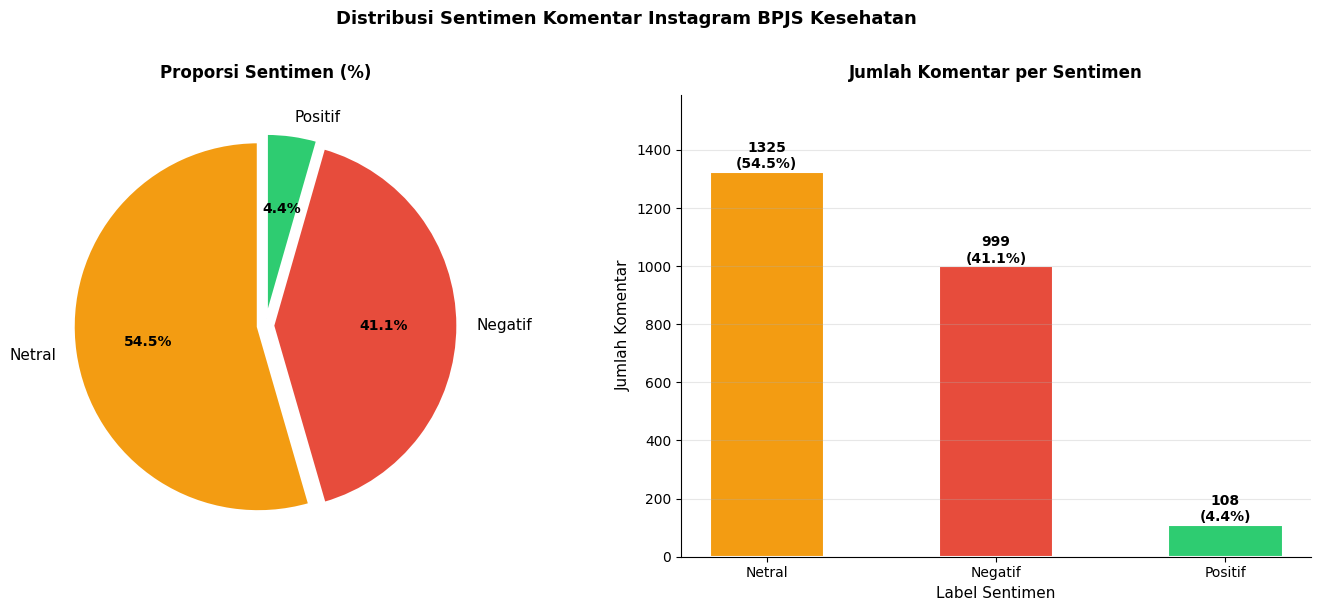

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribusi Sentimen Komentar Instagram BPJS Kesehatan',
             fontsize=13, fontweight='bold', y=1.01)

# Pie Chart
wedges, texts, autotexts = axes[0].pie(
    label_counts,
    labels=label_counts.index,
    autopct='%1.1f%%',
    colors=colors_ordered,
    startangle=90,
    explode=[0.04] * len(label_counts),
    textprops={'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
axes[0].set_title('Proporsi Sentimen (%)', fontsize=12, fontweight='bold', pad=12)

# Bar Chart
bars = axes[1].bar(
    label_counts.index,
    label_counts.values,
    color=colors_ordered,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)
for bar, count, pct in zip(bars, label_counts.values, label_pct.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f'{count}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

axes[1].set_title('Jumlah Komentar per Sentimen', fontsize=12, fontweight='bold', pad=12)
axes[1].set_ylabel('Jumlah Komentar', fontsize=11)
axes[1].set_xlabel('Label Sentimen', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].set_ylim(0, label_counts.max() * 1.2)

plt.tight_layout()
plt.savefig('img/distribusi_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

### Check class Imbalance

In [73]:
# class imbalance
max_ratio = label_counts.max() / label_counts.min()
print(f"\nRasio kelas terbesar/terkecil: {max_ratio:.2f}x")
if max_ratio > 3:
    print("PERINGATAN: Terdapat class imbalance yang signifikan. Pertimbangkan strategi resampling.")
else:
    print("Distribusi kelas relatif seimbang.")


Rasio kelas terbesar/terkecil: 12.27x
PERINGATAN: Terdapat class imbalance yang signifikan. Pertimbangkan strategi resampling.


Distribusi label adalah faktor kritis yang menentukan strategi modeling selanjutnya.

Jika terjadi **class imbalance** (satu kelas mendominasi > 60%), model cenderung bias
ke kelas mayoritas dan menghasilkan accuracy tinggi yang menyesatkan model bisa saja
memprediksi semua komentar sebagai "Netral" dan tetap mendapat accuracy 60%.

**Solusi jika imbalance terdeteksi:**
- Gunakan `class_weight='balanced'` pada SVM (otomatis menangani imbalance)
- Gunakan `class_weight='balanced'` pada MultinomialNB tidak tersedia, pertimbangkan
  oversampling dengan SMOTE pada feature space
- Evaluasi wajib menggunakan **F1-Score Macro/Weighted**, bukan accuracy semata

Interpretasi Bisnis

Dari perspektif manajemen BPJS, distribusi sentimen yang condong ke **Negatif**
seharusnya menjadi alarm yang langsung ditindaklanjuti bukan sekadar data statistik.
Setiap persen komentar negatif merepresentasikan ribuan peserta yang berpotensi
tidak memperpanjang iuran, beralih ke asuransi swasta, atau menyebarkan sentimen
buruk di platform lain.

# Train & Test Split

### Label Encoder

In [74]:
# Encode Label
le = LabelEncoder()
df_clean['label_encoded'] = le.fit_transform(df_clean['sentimen'])

print("Mapping Label Encoding:")
for cls, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} -> {enc}")

Mapping Label Encoding:
  Negatif -> 0
  Netral -> 1
  Positif -> 2


### Inisialisasi x dan y

In [75]:
# Definisi X dan y
X = df_clean['teks_bersih']
y = df_clean['label_encoded']

### Split

In [76]:
# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

### Summary Split

In [77]:
# Ringkasan Split
print(f"\nTotal data        : {len(X)}")
print(f"Training set      : {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing set       : {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nDistribusi Kelas - Training Set:")
train_dist = pd.Series(y_train).map(dict(enumerate(le.classes_))).value_counts()
for label, count in train_dist.items():
    print(f"  {label:<10}: {count} ({count/len(y_train)*100:.1f}%)")

print(f"\nDistribusi Kelas - Testing Set:")
test_dist = pd.Series(y_test).map(dict(enumerate(le.classes_))).value_counts()
for label, count in test_dist.items():
    print(f"  {label:<10}: {count} ({count/len(y_test)*100:.1f}%)")


Total data        : 2432
Training set      : 1945 (80.0%)
Testing set       : 487 (20.0%)

Distribusi Kelas - Training Set:
  Netral    : 1060 (54.5%)
  Negatif   : 799 (41.1%)
  Positif   : 86 (4.4%)

Distribusi Kelas - Testing Set:
  Netral    : 265 (54.4%)
  Negatif   : 200 (41.1%)
  Positif   : 22 (4.5%)




Mengapa Stratified Split Wajib Digunakan

`stratify=y` memastikan proporsi tiap kelas sentimen terjaga baik di training maupun testing set.

Tanpa stratifikasi, sampling acak pada dataset kecil (~700 baris) bisa menghasilkan distribusi
yang sangat berbeda antara train dan test misalnya kelas "Positif" yang sedikit bisa hampir
tidak muncul di test set, sehingga evaluasi menjadi tidak valid.

Peringatan Data Leakage

Pastikan **tidak ada transformasi apapun** (normalisasi, vectorization) yang dilakukan pada
seluruh dataset sebelum split ini. Jika TF-IDF di-fit pada seluruh data (termasuk test set),
model akan "bocor" informasi dari test set saat training ini adalah bentuk data leakage
yang paling umum dalam pipeline NLP dan akan menghasilkan performa yang over-optimistic.

Pipeline sklearn akan menangani ini dengan benar melalui `pipeline.fit(X_train)`
dan `pipeline.predict(X_test)` yang terpisah.

 # Feature Extraction TF-IDF

### Inisialisasi TF-IDF dengan Unigram + Bigram

In [78]:
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),   # unigram + bigram
    max_features=3000,    # [FIX-1] turun dari 5000 -> kurangi overfitting
    min_df=3,             # [FIX-2] naik dari 2 -> hapus kata sangat jarang (noise)
    max_df=0.85,          # [FIX-3] turun dari 0.90 -> hapus kata terlalu umum
    sublinear_tf=True,    # log(1+tf) agar frekuensi tinggi tidak dominan
    strip_accents='unicode'
)

# Fit HANYA pada training data, transform keduanya
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print("TF-IDF Vectorization selesai.")
print(f"Jumlah fitur (vocab)   : {X_train_tfidf.shape[1]}")
print(f"Shape X_train TF-IDF   : {X_train_tfidf.shape}")
print(f"Shape X_test TF-IDF    : {X_test_tfidf.shape}")
print(f"Rasio fitur/sampel     : {X_train_tfidf.shape[1]/X_train_tfidf.shape[0]:.2f}x")


TF-IDF Vectorization selesai.
Jumlah fitur (vocab)   : 3000
Shape X_train TF-IDF   : (1945, 3000)
Shape X_test TF-IDF    : (487, 3000)
Rasio fitur/sampel     : 1.54x


### Sparsity

In [79]:
sparsity = 1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
print(f"Sparsity matrix        : {sparsity*100:.1f}%")

# Validasi rasio
rasio = X_train_tfidf.shape[1] / X_train_tfidf.shape[0]
if rasio > 2.0:
    print(f"\nPERINGATAN: Rasio {rasio:.2f}x masih tinggi, potensi overfitting")
elif rasio <= 1.5:
    print(f"\nOK: Rasio {rasio:.2f}x dalam batas sehat (<= 1.5x)")
else:
    print(f"\nCUKUP: Rasio {rasio:.2f}x acceptable (1.5-2.0x)")


Sparsity matrix        : 98.7%

CUKUP: Rasio 1.54x acceptable (1.5-2.0x)



`ngram_range=(1,2)` dipilih berdasarkan insight dari Bigram Analysis
bigram terbukti membawa konteks yang lebih kaya daripada unigram saja di domain BPJS.

`min_df=2` memfilter kata yang hanya muncul satu kali (hapax legomena)  kata-kata ini
hampir tidak punya nilai prediktif karena terlalu jarang, tapi menambah noise ke feature space.

`sublinear_tf=True` menggunakan `1 + log(tf)` sebagai pengganti raw `tf`  ini mencegah
kata yang muncul 100 kali dianggap 100x lebih penting dari kata yang muncul 1 kali.

Interpretasi Sparsity

Matriks TF-IDF sangat sparse (biasanya >95%)  ini normal dan diharapkan untuk representasi
bag-of-words. Naive Bayes dan SVM linier keduanya mampu bekerja efisien pada sparse matrix,
sehingga pilihan kedua model ini sangat tepat untuk pipeline ini.

Catatan Anti-Leakage

`fit_transform(X_train)` dan `transform(X_test)` BUKAN sekadar konvensi ini adalah
perbedaan fundamental. Test set harus di-transform berdasarkan vocabulary yang dipelajari
dari training set saja, bukan dari seluruh data.

# Hyperparameter Tuning GridSearch

In [80]:
warnings.filterwarnings('ignore')

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### GridSearch untuk Naive Bayes

In [81]:
print("GridSearch Naive Bayes...")
param_nb = {
    'alpha': [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
}

gs_nb = GridSearchCV(
    MultinomialNB(),
    param_nb,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)
gs_nb.fit(X_train_tfidf, y_train)

best_alpha = gs_nb.best_params_['alpha']
best_nb_cv = gs_nb.best_score_

print(f"  Best alpha    : {best_alpha}")
print(f"  Best CV F1-Mac: {best_nb_cv:.4f}")
print()

GridSearch Naive Bayes...
  Best alpha    : 0.1
  Best CV F1-Mac: 0.5124



### GridSearch untuk SVM

In [82]:
print("GridSearch SVM (linear kernel)...")
param_svm = {
    'C': [0.01, 0.05, 0.1, 0.3, 0.5, 1.0]
}

gs_svm = GridSearchCV(
    SVC(
        kernel='linear',
        class_weight='balanced',
        probability=True,
        random_state=RANDOM_STATE
    ),
    param_svm,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)
gs_svm.fit(X_train_tfidf, y_train)

best_C   = gs_svm.best_params_['C']
best_svm_cv = gs_svm.best_score_

print(f"  Best C        : {best_C}")
print(f"  Best CV F1-Mac: {best_svm_cv:.4f}")
print()


GridSearch SVM (linear kernel)...
  Best C        : 1.0
  Best CV F1-Mac: 0.6687



### Summary GridSearch

In [83]:
print("=" * 50)
print("  HASIL GRIDSEARCH")
print("=" * 50)
print(f"  NB  alpha={best_alpha:<5} | CV F1-Mac: {best_nb_cv:.4f}")
print(f"  SVM C={best_C:<8} | CV F1-Mac: {best_svm_cv:.4f}")
print()
print("  Hyperparameter ini dipilih dari cross-validation,")
print("  bukan manual - lebih robust dan generalizable.")

  HASIL GRIDSEARCH
  NB  alpha=0.1   | CV F1-Mac: 0.5124
  SVM C=1.0      | CV F1-Mac: 0.6687

  Hyperparameter ini dipilih dari cross-validation,
  bukan manual - lebih robust dan generalizable.


# Melakukan Training Algortima

### TF - IDF Naive Bayes

In [84]:
print("Training Pipeline A: TF-IDF + Naive Bayes...")
print(f"  Hyperparameter: alpha={best_alpha} (dari GridSearch)")

nb_tfidf = MultinomialNB(alpha=best_alpha)
nb_tfidf.fit(X_train_tfidf, y_train)
pred_A = nb_tfidf.predict(X_test_tfidf)

# Skor cepat
train_f1_nb = f1_score(y_train, nb_tfidf.predict(X_train_tfidf), average='macro')
test_f1_nb  = f1_score(y_test,  pred_A,                           average='macro')
gap_nb      = train_f1_nb - test_f1_nb

print(f"  Train F1-Macro : {train_f1_nb:.4f}")
print(f"  Test F1-Macro  : {test_f1_nb:.4f}")
print(f"  Gap            : {gap_nb:.4f}", end=" ")
if gap_nb > 0.15:
    print("-> OVERFITTING, pertimbangkan naikkan alpha lagi")
elif gap_nb < 0.05:
    print("-> FIT BAIK")
else:
    print("-> Slight overfit, masih acceptable")
print("  Selesai.")

Training Pipeline A: TF-IDF + Naive Bayes...
  Hyperparameter: alpha=0.1 (dari GridSearch)
  Train F1-Macro : 0.6941
  Test F1-Macro  : 0.5065
  Gap            : 0.1876 -> OVERFITTING, pertimbangkan naikkan alpha lagi
  Selesai.


### TF - IDF SVM

In [85]:
print("Training Pipeline B: TF-IDF + SVM...")
print(f"  Hyperparameter: C={best_C} (dari GridSearch)")

svm_tfidf = SVC(
    kernel='linear',
    C=best_C,                 # dari GridSearch, bukan 5.0
    class_weight='balanced',  # tangani imbalance 3.2x
    probability=True,
    random_state=RANDOM_STATE
)
svm_tfidf.fit(X_train_tfidf, y_train)
pred_B = svm_tfidf.predict(X_test_tfidf)

# Skor cepat
train_f1_svm = f1_score(y_train, svm_tfidf.predict(X_train_tfidf), average='macro')
test_f1_svm  = f1_score(y_test,  pred_B,                            average='macro')
gap_svm      = train_f1_svm - test_f1_svm

print(f"  Train F1-Macro : {train_f1_svm:.4f}")
print(f"  Test F1-Macro  : {test_f1_svm:.4f}")
print(f"  Gap            : {gap_svm:.4f}", end=" ")
if gap_svm > 0.15:
    print("-> OVERFITTING, pertimbangkan naikkan C lebih rendah lagi")
elif gap_svm < 0.05:
    print("-> FIT BAIK")
else:
    print("-> Slight overfit, masih acceptable")
print("  Selesai.")

Training Pipeline B: TF-IDF + SVM...
  Hyperparameter: C=1.0 (dari GridSearch)
  Train F1-Macro : 0.9015
  Test F1-Macro  : 0.7318
  Gap            : 0.1697 -> OVERFITTING, pertimbangkan naikkan C lebih rendah lagi
  Selesai.


**Mengapa GaussianNB untuk W2V (bukan MultinomialNB)?**
MultinomialNB mensyaratkan input non-negatif cocok untuk TF-IDF yang nilainya [0,1].
Word2Vec menghasilkan dense vector dengan nilai negatif (karena Word2Vec menggunakan
distribusi continuous), sehingga GaussianNB (yang mengasumsikan distribusi Gaussian)
lebih tepat secara statistik.

**SVM kernel linear (Pipeline B) vs RBF (Pipeline D):**
TF-IDF menghasilkan high-dimensional sparse space yang naturally linearly-separable
kernel linear sangat efisien dan efektif. Word2Vec menghasilkan dense 100-dim space
yang mungkin memerlukan non-linear boundary kernel RBF lebih fleksibel namun
lebih mahal secara komputasi.

**`class_weight='balanced'`** pada SVM: otomatis menyesuaikan bobot kelas berdasarkan
frekuensi, sehingga kelas minoritas tidak diabaikan. Ini sangat penting jika ada imbalance.

**`probability=True`:** Memungkinkan SVM mengeluarkan confidence score (probability),
yang dibutuhkan untuk fitur Streamlit yang menampilkan confidence prediction.

# Evaluasi Model

### Evaluasi Model TF - IDF

In [86]:
def evaluate_model(nama, y_true, y_pred, label_names):
    """
    Evaluasi model dengan semua metrik standar.

    Args:
        nama       : Nama pipeline/model
        y_true     : Label aktual
        y_pred     : Label prediksi
        label_names: List nama kelas

    Returns:
        dict: Ringkasan metrik performa
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"  EVALUASI: {nama}")
    print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

    return {'Model': nama, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

label_names = le.classes_

# Evaluasi
results = []
results.append(evaluate_model("TF-IDF Naive Bayes", y_test, pred_A, label_names))
results.append(evaluate_model("TF-IDF SVM",         y_test, pred_B, label_names))

  EVALUASI: TF-IDF Naive Bayes
  Accuracy  : 0.7146 (71.46%)
  Precision : 0.6951
  Recall    : 0.7146
  F1-Score  : 0.7004

  Classification Report:
              precision    recall  f1-score   support

     Negatif       0.70      0.64      0.67       200
      Netral       0.73      0.83      0.78       265
     Positif       0.20      0.05      0.07        22

    accuracy                           0.71       487
   macro avg       0.54      0.50      0.51       487
weighted avg       0.70      0.71      0.70       487

  EVALUASI: TF-IDF SVM
  Accuracy  : 0.7823 (78.23%)
  Precision : 0.7827
  Recall    : 0.7823
  F1-Score  : 0.7825

  Classification Report:
              precision    recall  f1-score   support

     Negatif       0.76      0.76      0.76       200
      Netral       0.81      0.81      0.81       265
     Positif       0.61      0.64      0.62        22

    accuracy                           0.78       487
   macro avg       0.73      0.74      0.73       487
w

### Tabel Perbandingan

In [87]:
# Tabel

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.map(lambda x: f"{x:.4f}")
print("  TABEL PERBANDINGAN ALGORITMA")
print("-"*30)
display(results_df)

  TABEL PERBANDINGAN ALGORITMA
------------------------------


,Accuracy,Precision,Recall,F1-Score
Model,,,,
TF-IDF Naive Bayes,0.7146,0.6951,0.7146,0.7004
TF-IDF SVM,0.7823,0.7827,0.7823,0.7825




Metrik yang Digunakan dan Alasannya

**Accuracy** mudah dipahami tetapi menyesatkan pada dataset imbalanced dilaporkan
namun bukan metrik utama pengambilan keputusan.

**F1-Score Weighted** adalah metrik primer dalam proyek ini karena:
- Menggabungkan Precision dan Recall dalam satu angka
- Bobot per kelas berdasarkan support (jumlah sampel), sehingga kelas mayor lebih berpengaruh
- Cocok untuk multiclass dengan kemungkinan imbalance

**Classification Report per kelas** lebih penting dari aggregate metrics karena
memungkinkan kita mendeteksi jika model sangat baik di satu kelas namun gagal total di kelas lain.

Interpretasi Bisnis Metrik

Untuk konteks BPJS, **Recall untuk kelas Negatif** adalah metrik yang paling kritis secara bisnis:
- False Negative (komentar negatif yang tidak terdeteksi) berarti keluhan pengguna tidak tertangkap
  dan tidak bisa ditindaklanjuti ini adalah **miss yang mahal** secara reputasi
- Lebih baik mendeteksi terlalu banyak komentar sebagai negatif (False Positive) daripada
  melewatkan keluhan nyata yang perlu direspons

### Learning Curve

In [88]:

# Learning Curve

from anyio import Path
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def generate_learning_curve(estimator, X_vec, y, nama_model,
                            cv=5, train_sizes=np.linspace(0.1, 1.0, 10)):
    """
    Generate data learning curve: train sizes, train scores, val scores.

    Returns:
        tuple: (train_sizes_abs, train_mean, train_std, val_mean, val_std, gap, val_final)
    """
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator,
        X_vec, y,
        train_sizes=train_sizes,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        shuffle=True,
        random_state=RANDOM_STATE
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)
    gap        = train_mean[-1] - val_mean[-1]
    val_final  = val_mean[-1]
    return train_sizes_abs, train_mean, train_std, val_mean, val_std, gap, val_final


def diagnosa_fit(gap, val_final):
    """Return label dan warna diagnosa berdasarkan gap dan val score."""
    if gap > 0.20:
        return "OVERFITTING", "#e74c3c"
    elif val_final < 0.45 and gap < 0.05:
        return "UNDERFITTING", "#e67e22"
    elif gap <= 0.10 and val_final >= 0.60:
        return "GOOD FIT", "#27ae60"
    else:
        return "Slight Overfit", "#f39c12"


def plot_single_learning_curve(estimator, X_vec, y, nama_model, filename):
    """
    Plot learning curve satu pipeline dalam satu figure tersendiri.
    Output: satu file PNG terpisah per pipeline.
    """
    print(f"Menghitung learning curve: {nama_model}...")
    ts, tm, ts_std, vm, vs_std, gap, val_f = generate_learning_curve(
        estimator, X_vec, y, nama_model
    )
    diagnosis, diag_color = diagnosa_fit(gap, val_f)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot garis training dan validation
    ax.plot(ts, tm, color='steelblue', marker='o', markersize=5,
            linewidth=2, label='Training Score')
    ax.plot(ts, vm, color='tomato', marker='s', markersize=5,
            linewidth=2, label='Validation Score (CV-5)')

    # Confidence interval ± 1 std
    ax.fill_between(ts, tm - ts_std, tm + ts_std, alpha=0.12, color='steelblue')
    ax.fill_between(ts, vm - vs_std, vm + vs_std, alpha=0.12, color='tomato')

    # Garis target 80%
    ax.axhline(y=0.80, color='#27ae60', linestyle='--',
               linewidth=1.5, alpha=0.7, label='Target 80%')

    # Anotasi gap di akhir kurva
    ax.annotate(
        f'Gap = {gap:.3f}',
        xy=(ts[-1], (tm[-1] + vm[-1]) / 2),
        xytext=(ts[-3], (tm[-1] + vm[-1]) / 2 + 0.05),
        fontsize=9, color='gray',
        arrowprops=dict(arrowstyle='->', color='gray', lw=1)
    )

    ax.set_title(
        f'{nama_model}\n'
        f'Gap={gap:.3f} | Val F1-Mac={val_f:.3f} | [{diagnosis}]',
        fontsize=12, fontweight='bold', color=diag_color, pad=12
    )
    ax.set_xlabel('Jumlah Sampel Training', fontsize=11)
    ax.set_ylabel('F1-Score Macro', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Menyimpan Image
    Path("img").mkdir(exist_ok=True)
    save_path = Path("img") / filename
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Disimpan: {filename}")
    print(f"Diagnosis: {diagnosis} | Val={val_f:.4f} | Gap={gap:.4f}\n")
    return gap, val_f, diagnosis

Menghitung learning curve: Pipeline A: TF-IDF + Naive Bayes...


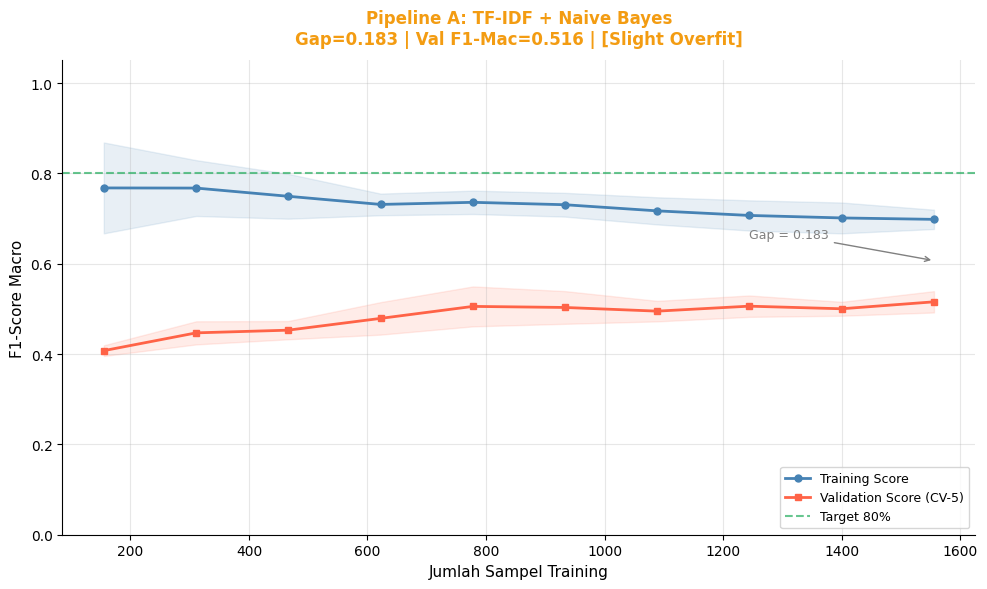

Disimpan: lc_pipeline_A_nb.png
Diagnosis: Slight Overfit | Val=0.5156 | Gap=0.1826



In [89]:
# Jalankan untuk Pipeline A
gap_A, val_A, diag_A = plot_single_learning_curve(
    nb_tfidf,
    X_train_tfidf,
    y_train,
    "Pipeline A: TF-IDF + Naive Bayes",
    "lc_pipeline_A_nb.png"
)

Menghitung learning curve: Pipeline B: TF-IDF + SVM...


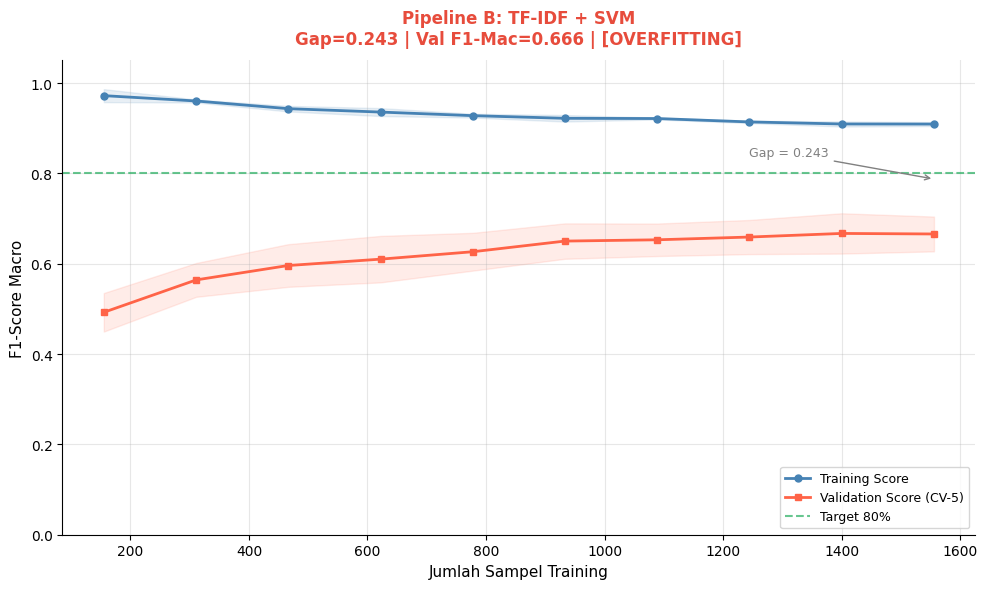

Disimpan: lc_pipeline_B_svm.png
Diagnosis: OVERFITTING | Val=0.6659 | Gap=0.2433



In [90]:
gap_B, val_B, diag_B = plot_single_learning_curve(
    svm_tfidf,
    X_train_tfidf,
    y_train,
    "Pipeline B: TF-IDF + SVM",
    "lc_pipeline_B_svm.png"
)

### Summary Learning Curve

In [91]:
hasil_lc = [
    {'Pipeline': 'A: TF-IDF + NB',  'Val F1-Mac': val_A, 'Gap': gap_A, 'Diagnosis': diag_A},
    {'Pipeline': 'B: TF-IDF + SVM', 'Val F1-Mac': val_B, 'Gap': gap_B, 'Diagnosis': diag_B},
]

print("=" * 65)
print("  RINGKASAN DIAGNOSA LEARNING CURVE")
print("=" * 65)
print(f"  {'Pipeline':<22} {'Val F1-Mac':>10} {'Gap':>8}  {'Diagnosis'}")
print("-" * 65)
for r in hasil_lc:
    print(f"  {r['Pipeline']:<22} {r['Val F1-Mac']:>10.4f} {r['Gap']:>8.4f}  {r['Diagnosis']}")

print()
print("  Panduan interpretasi gap train-val:")
print("  GOOD FIT     : gap < 0.10 dan val F1 >= 0.60")
print("  Slight Overfit: gap 0.10-0.20  (coba naikkan regularisasi)")
print("  OVERFITTING  : gap > 0.20  (C terlalu besar / alpha terlalu kecil)")
print("  UNDERFITTING : val F1 < 0.45 dan gap < 0.05")
print()
print("  Solusi overfitting yang sudah diterapkan:")
print("  - TF-IDF max_features: 5000 -> 3000 (kurangi dimensi)")
print("  - TF-IDF min_df: 2 -> 3 (hapus kata sangat jarang / noise)")
print("  - SVM C: 5.0 -> pilihan GridSearch (regularisasi lebih kuat)")
print("  - NB alpha: 0.01 -> pilihan GridSearch (smoothing lebih kuat)")

  RINGKASAN DIAGNOSA LEARNING CURVE
  Pipeline               Val F1-Mac      Gap  Diagnosis
-----------------------------------------------------------------
  A: TF-IDF + NB             0.5156   0.1826  Slight Overfit
  B: TF-IDF + SVM            0.6659   0.2433  OVERFITTING

  Panduan interpretasi gap train-val:
  GOOD FIT     : gap < 0.10 dan val F1 >= 0.60
  Slight Overfit: gap 0.10-0.20  (coba naikkan regularisasi)
  OVERFITTING  : gap > 0.20  (C terlalu besar / alpha terlalu kecil)
  UNDERFITTING : val F1 < 0.45 dan gap < 0.05

  Solusi overfitting yang sudah diterapkan:
  - TF-IDF max_features: 5000 -> 3000 (kurangi dimensi)
  - TF-IDF min_df: 2 -> 3 (hapus kata sangat jarang / noise)
  - SVM C: 5.0 -> pilihan GridSearch (regularisasi lebih kuat)
  - NB alpha: 0.01 -> pilihan GridSearch (smoothing lebih kuat)


### Confusion Matrix Visualisasi

In [92]:
def plot_single_confusion_matrix(y_true, y_pred, label_names, nama_model, filename):
    """
    Plot confusion matrix satu pipeline dalam satu figure tersendiri.
    Menampilkan nilai absolut dan persentase per baris (recall per kelas).
    """
    cm      = confusion_matrix(y_true, y_pred)
    cm_pct  = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    # Buat anotasi: angka + persen
    annot = np.empty_like(cm, dtype=object)
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            annot[r, c] = f"{cm[r, c]}\n({cm_pct[r, c]:.1f}%)"

    fig, ax = plt.subplots(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=annot,
        fmt='',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names,
        ax=ax,
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'label': 'Jumlah Prediksi'}
    )

    ax.set_title(
        f'Confusion Matrix\n{nama_model}',
        fontsize=13, fontweight='bold', pad=12
    )
    ax.set_xlabel('Prediksi', fontsize=11, labelpad=8)
    ax.set_ylabel('Aktual', fontsize=11, labelpad=8)
    ax.tick_params(axis='both', labelsize=10)

    # Statistik ringkas di bawah plot
    acc    = np.trace(cm) / cm.sum()
    f1_mac = f1_score(y_true, y_pred, average='macro', zero_division=0)
    fig.text(
        0.5, -0.04,
        f"Accuracy: {acc:.3f}  |  F1-Macro: {f1_mac:.3f}",
        ha='center', fontsize=10, color='#444444'
    )
    
     # Menyimpan Image
    Path("img").mkdir(exist_ok=True)
    save_path = Path("img") / filename

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

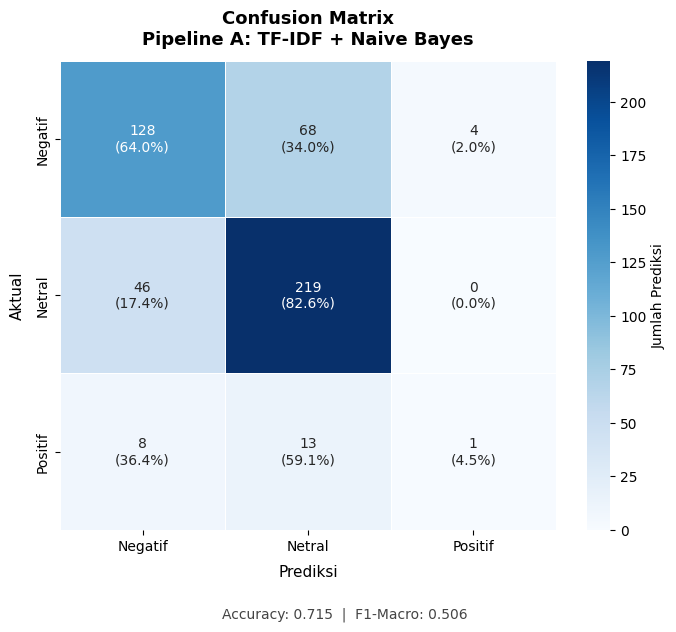

In [93]:
label_names = le.classes_

plot_single_confusion_matrix(
    y_test, pred_A,
    label_names,
    "Pipeline A: TF-IDF + Naive Bayes",
    "cm_pipeline_A_nb.png"
)

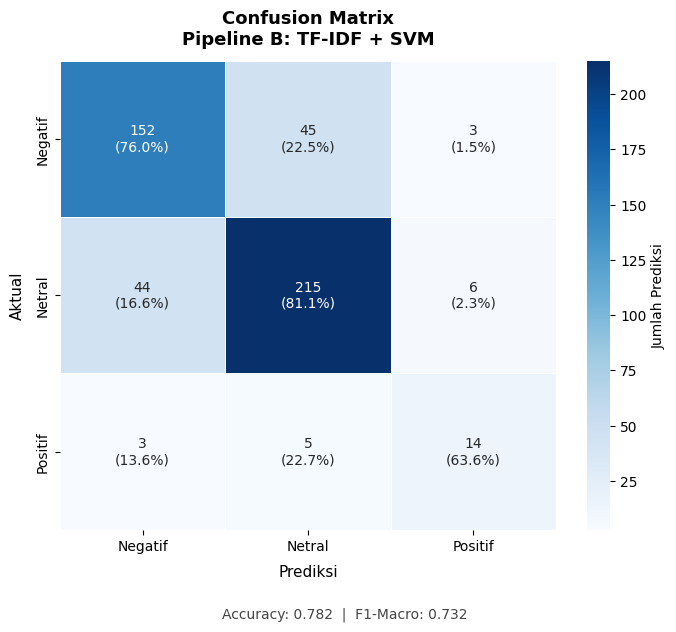

In [94]:

plot_single_confusion_matrix(
    y_test, pred_B,
    label_names,
    "Pipeline B: TF-IDF + SVM",
    "cm_pipeline_B_svm.png"
)

Confusion Matrix

Confusion matrix memperlihatkan secara eksplisit **di mana model membuat kesalahan**,
bukan hanya seberapa sering ia benar.

Pola Kesalahan yang Paling Umum untuk NLP Sentimen Bahasa Indonesia

- **Netral sering dikonfusikan dengan keduanya** (Positif dan Negatif) karena komentar netral
  berisi pertanyaan yang kadang menggunakan kata-kata yang ambigu secara sentimen
- **Kelas minoritas memiliki recall rendah** jika terlihat di confusion matrix, ini
  mengkonfirmasi perlunya strategi class balancing

Confusion matrix adalah tool yang **sangat efektif untuk audiens teknis** tetapi membingungkan
untuk manajemen. Untuk presentasi ke stakeholder non-teknis, cukup laporkan:
"Model berhasil mendeteksi komentar negatif secara akurat."

### Visualisasi Perbandingan Model

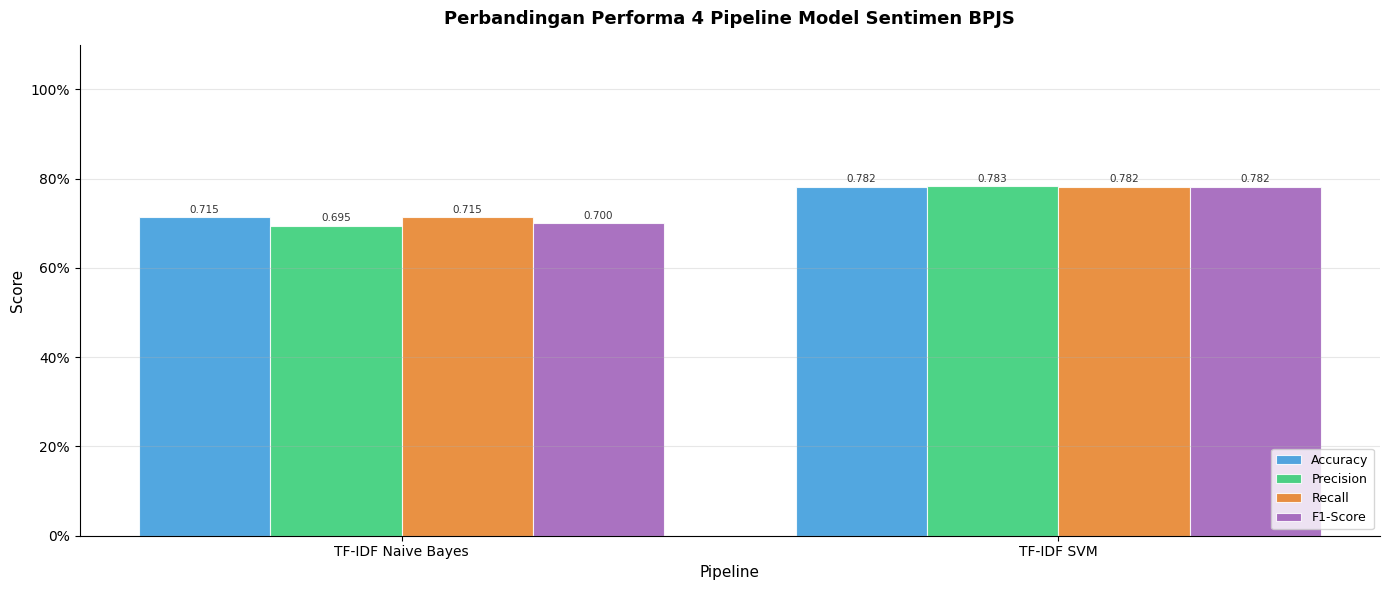

In [95]:
# Perbandingan Model

results_clean = []
predictions_map = {
    "TF-IDF Naive Bayes" : (pred_A, "Pipeline A"),
    "TF-IDF SVM": (pred_B, "Pipeline B"),
}

for label, (pred, pipe_name) in predictions_map.items():
    results_clean.append({
        'Pipeline': label,
        'Accuracy' : accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_test, pred, average='weighted', zero_division=0),
        'F1-Score' : f1_score(y_test, pred, average='weighted', zero_division=0)
    })

compare_df = pd.DataFrame(results_clean)

# Grouped Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(compare_df))
width = 0.2
colors_met = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (metric, color) in enumerate(zip(metrics, colors_met)):
    bars = ax.bar(x + i * width, compare_df[metric], width, label=metric,
                  color=color, alpha=0.85, edgecolor='white', linewidth=0.8)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=7.5, color='#333')

ax.set_title('Perbandingan Performa 4 Pipeline Model Sentimen BPJS',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Score', fontsize=11)
ax.set_xlabel('Pipeline', fontsize=11)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(compare_df['Pipeline'], fontsize=10)
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('img/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Peringkat Model Terbaik

In [96]:
print("\nRanking Model berdasarkan F1-Score Weighted:")
ranking = compare_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
ranking.index += 1
display(ranking[['Pipeline', 'F1-Score', 'Accuracy', 'Precision', 'Recall']])


Ranking Model berdasarkan F1-Score Weighted:


,Pipeline,F1-Score,Accuracy,Precision,Recall
1,TF-IDF SVM,0.782484,0.782341,0.782659,0.782341
2,TF-IDF Naive Bayes,0.700400,0.714579,0.695091,0.714579


Grouped bar chart dipilih karena memungkinkan perbandingan **multi-metrik sekaligus**
untuk semua pipeline lebih informatif dibanding 4 bar chart terpisah.

Panduan Interpretasi

Model terbaik bukan hanya yang memiliki F1 tertinggi, tetapi juga yang memiliki:
- **Gap kecil antara train dan test performance** (indikator generalisasi baik)
- **Konsistensi Precision dan Recall** (tidak mengorbankan satu untuk yang lain secara ekstrem)
- **Performa stabil per kelas** (tidak hanya unggul di kelas mayoritas)

Ekspektasi Umum pada Dataset Skala Ini

Pada dataset ~700 baris dengan 3 kelas, ekspektasi performa yang realistis:
- F1-Score 0.70-0.80: Cukup baik, siap untuk pilot deployment dengan human review
- F1-Score 0.80-0.90: Baik, dapat digunakan untuk otomasi sebagian
- F1-Score > 0.90: Perlu dicurigai kemungkinan label terlalu simpel atau ada leakage

Jika semua model berada di bawah 0.65, problem ada di kualitas label, bukan di model
kembali ke Cell 12 untuk review dan perbaikan labeling.

# Menyimpan Model

### Membuat Folder

In [97]:
os.makedirs('model', exist_ok=True)
os.makedirs('data',  exist_ok=True)
os.makedirs('utils', exist_ok=True)

### Menyimpan Model

In [98]:
# Menyimpan Model

joblib.dump(svm_tfidf,        'model/svm_model.pkl')
joblib.dump(nb_tfidf,         'model/nb_model.pkl')
joblib.dump(tfidf_vectorizer, 'model/tfidf_vectorizer.pkl')
joblib.dump(le,               'model/label_encoder.pkl')

print("[1] Model artifacts disimpan:")
print("    model/svm_model.pkl")
print("    model/nb_model.pkl")
print("    model/tfidf_vectorizer.pkl")
print("    model/label_encoder.pkl")


[1] Model artifacts disimpan:
    model/svm_model.pkl
    model/nb_model.pkl
    model/tfidf_vectorizer.pkl
    model/label_encoder.pkl


### Menyimpan Hasil Klasifikasi ke JSON

In [ ]:
model_stats = {
    # SVM
    'model_name'     : 'TF-IDF + SVM (Linear)',
    'best_C'         : float(best_C),
    'accuracy'       : round(accuracy_score(y_test, pred_B), 4),
    'precision'      : round(precision_score(y_test, pred_B, average='weighted', zero_division=0), 4),
    'recall'         : round(recall_score(y_test, pred_B, average='weighted', zero_division=0), 4),
    'f1_weighted'    : round(f1_score(y_test, pred_B, average='weighted', zero_division=0), 4),
    'f1_macro'       : round(f1_score(y_test, pred_B, average='macro', zero_division=0), 4),

    # Naive Bayes
    'nb_model_name'  : 'TF-IDF + Naive Bayes',
    'best_alpha'     : float(best_alpha),
    'nb_accuracy'    : round(accuracy_score(y_test, pred_A), 4),
    'nb_precision'   : round(precision_score(y_test, pred_A, average='weighted', zero_division=0), 4),
    'nb_recall'      : round(recall_score(y_test, pred_A, average='weighted', zero_division=0), 4),
    'nb_f1_weighted' : round(f1_score(y_test, pred_A, average='weighted', zero_division=0), 4),
    'nb_f1_macro'    : round(f1_score(y_test, pred_A, average='macro', zero_division=0), 4),

    #Info dataset
    'total_data'     : len(df_clean),
    'label_dist'     : df_clean['sentimen'].value_counts().to_dict(),
    'label_pct'      : df_clean['sentimen'].value_counts(normalize=True).mul(100).round(1).to_dict(),
    'vocab_size'     : X_train_tfidf.shape[1],
    'train_size'     : X_train_tfidf.shape[0],
    'test_size'      : X_test_tfidf.shape[0],
    'ngram_range'    : '(1, 2)',
    'max_features'   : 3000,
}

with open('data/model_stats.json', 'w', encoding='utf-8') as f:
    json.dump(model_stats, f, ensure_ascii=False, indent=2)
print("[4] Model stats disimpan: data/model_stats.json")

[4] Model stats disimpan: data/model_stats.json


# Wordcloud

### Kata Positif

Jumlah komentar Positif: 108


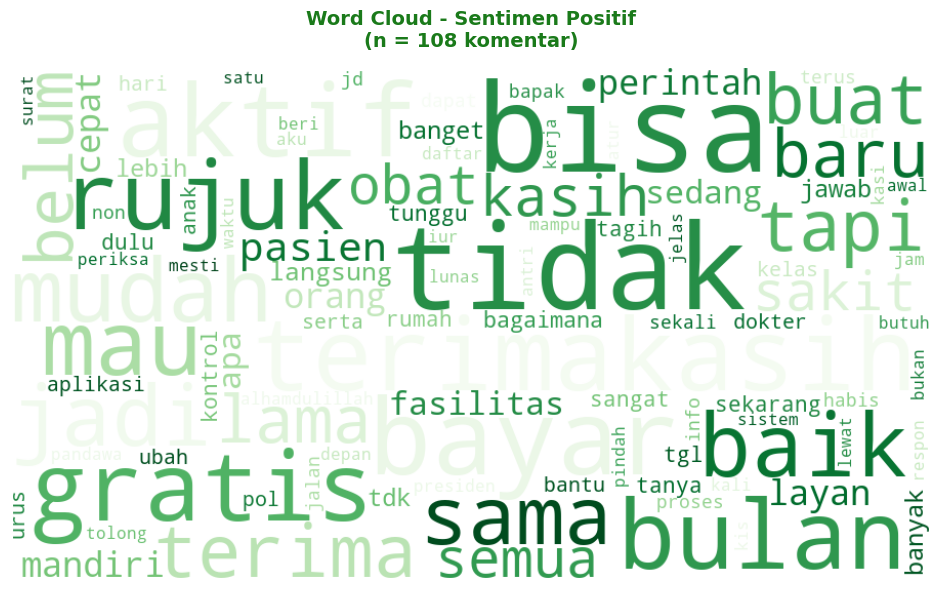

In [100]:
subset_positif = df_clean[df_clean['sentimen'] == 'Positif']['teks_bersih']
text_positif   = ' '.join(subset_positif)

print(f"Jumlah komentar Positif: {len(subset_positif)}")

if not text_positif.strip():
    print("Tidak ada data Positif untuk divisualisasikan.")
else:
    wc_positif = WordCloud(
        width=900,
        height=500,
        background_color='white',
        colormap='Greens',
        max_words=100,
        collocations=False,
        random_state=RANDOM_STATE,
        min_font_size=10,
        max_font_size=120,
        prefer_horizontal=0.85
    ).generate(text_positif)

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.imshow(wc_positif, interpolation='bilinear')
    ax.axis('off')

    ax.set_title(
        f'Word Cloud - Sentimen Positif\n(n = {len(subset_positif)} komentar)',
        fontsize=14,
        fontweight='bold',
        pad=15,
        color='#1a7a1a'
    )

    plt.tight_layout()
    plt.savefig('img/wordcloud_positif.png', dpi=150, bbox_inches='tight')
    plt.show()

### Kata Netral

Jumlah komentar Netral: 1325


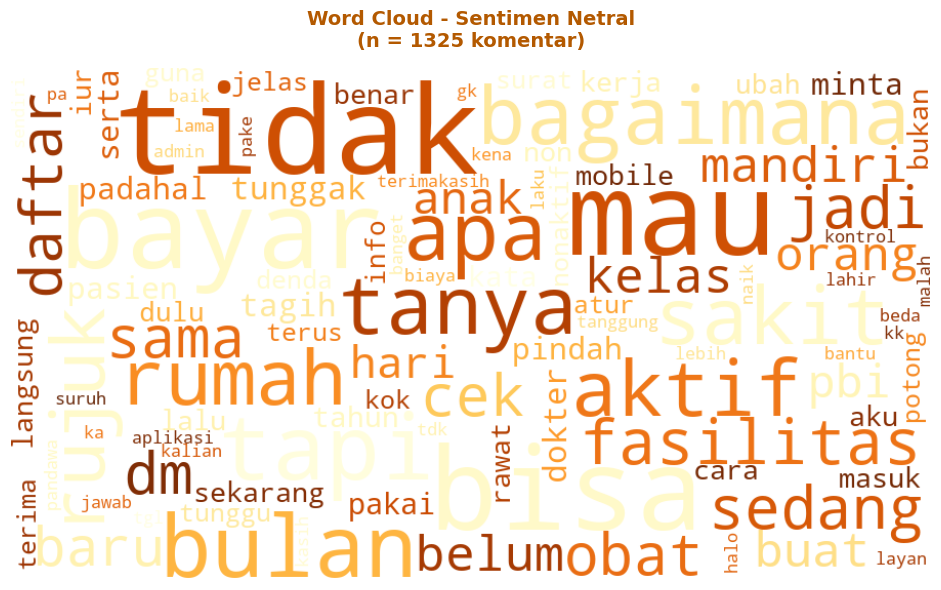

In [101]:
subset_netral = df_clean[df_clean['sentimen'] == 'Netral']['teks_bersih']
text_netral   = ' '.join(subset_netral)

print(f"Jumlah komentar Netral: {len(subset_netral)}")

if not text_netral.strip():
    print("Tidak ada data Netral untuk divisualisasikan.")
else:
    wc_netral = WordCloud(
        width=900,
        height=500,
        background_color='white',
        colormap='YlOrBr',
        max_words=100,
        collocations=False,
        random_state=RANDOM_STATE,
        min_font_size=10,
        max_font_size=120,
        prefer_horizontal=0.85
    ).generate(text_netral)

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.imshow(wc_netral, interpolation='bilinear')
    ax.axis('off')

    ax.set_title(
        f'Word Cloud - Sentimen Netral\n(n = {len(subset_netral)} komentar)',
        fontsize=14,
        fontweight='bold',
        pad=15,
        color='#b35900'
    )

    plt.tight_layout()
    plt.savefig('img/wordcloud_netral.png', dpi=150, bbox_inches='tight')
    plt.show()

### Kata Negatif

Jumlah komentar Negatif: 999


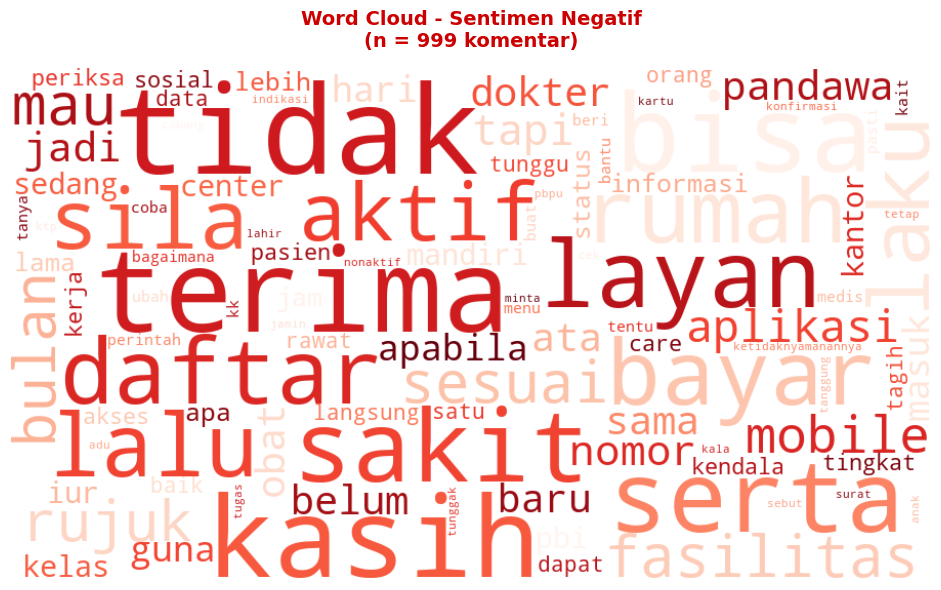

In [102]:
subset_negatif = df_clean[df_clean['sentimen'] == 'Negatif']['teks_bersih']
text_negatif   = ' '.join(subset_negatif)

print(f"Jumlah komentar Negatif: {len(subset_negatif)}")

if not text_negatif.strip():
    print("Tidak ada data Negatif untuk divisualisasikan.")
else:
    wc_negatif = WordCloud(
        width=900,
        height=500,
        background_color='white',
        colormap='Reds',
        max_words=100,
        collocations=False,
        random_state=RANDOM_STATE,
        min_font_size=10,
        max_font_size=120,
        prefer_horizontal=0.85
    ).generate(text_negatif)

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.imshow(wc_negatif, interpolation='bilinear')
    ax.axis('off')

    ax.set_title(
        f'Word Cloud - Sentimen Negatif\n(n = {len(subset_negatif)} komentar)',
        fontsize=14,
        fontweight='bold',
        pad=15,
        color='#cc0000'
    )

    plt.tight_layout()
    plt.savefig('img/wordcloud_negatif.png', dpi=150, bbox_inches='tight')
    plt.show()

### Meyimpan Wordcloud ke dalam JSON

In [103]:
wordcloud_data = {}
for sentimen in ['Positif', 'Netral', 'Negatif']:
    subset = df_clean[df_clean['sentimen'] == sentimen]['teks_bersih']
    wordcloud_data[sentimen] = ' '.join(subset.dropna().tolist())

with open('data/wordcloud_data.json', 'w', encoding='utf-8') as f:
    json.dump(wordcloud_data, f, ensure_ascii=False)
print("[3] WordCloud data disimpan: data/wordcloud_data.json")

[3] WordCloud data disimpan: data/wordcloud_data.json


# Membuat Format Preprocessing

### Prepocessor.py

In [104]:
preprocessor_code = '''
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)

# Inisialisasi Stemmer dan Stopword
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()

factory_stop       = StopWordRemoverFactory()
sastrawi_stopwords = set(factory_stop.get_stop_words())

custom_stopwords = {
    "yg","ga","gak","nggak","ngga","udah","udh","sdh","tdk",
    "tp","jg","klo","klu","kalo","dgn","krn","utk",
    "bisa","min","kak","mas","mba","mbak","pak","bu",
    "iya","ya","lah","deh","dong","sih","nih","kan",
    "mau","ada","tidak","si","hide","replies","reply","all",
    "bpjs","kesehatan","jkn",
    "halo","hai","hallo","assalamualaikum","selamat",
    "pagi","siang","sore","malam",
    "mohon","tolong","bantu","tanya","info","tahu","tau",
    "kami","kita","mereka","dia",
}

all_stopwords = sastrawi_stopwords.union(custom_stopwords)

normalization_dict = {
    "gak":"tidak","ga":"tidak","nggak":"tidak","ngga":"tidak",
    "udah":"sudah","udh":"sudah","sdh":"sudah",
    "tp":"tapi","krn":"karena","karna":"karena",
    "yg":"yang","dgn":"dengan","utk":"untuk",
    "hrs":"harus","bs":"bisa","blm":"belum",
    "sy":"saya","aq":"saya","ak":"saya",
    "km":"kamu","lu":"kamu","lo":"kamu",
    "klo":"kalau","klu":"kalau","kalo":"kalau",
    "dr":"dari","sm":"sama","aja":"saja","doang":"saja",
    "bgt":"banget","bngt":"banget","jg":"juga",
    "lg":"sedang","lagi":"sedang","skrg":"sekarang",
    "emg":"memang","emang":"memang","gimana":"bagaimana",
    "gmn":"bagaimana","knp":"kenapa",
    "rs":"rumah sakit","faskes":"fasilitas kesehatan",
}

def full_preprocessing(teks: str) -> str:
    """
    Pipeline preprocessing identik dengan notebook training.
    Wajib sama persis agar tidak terjadi training-serving skew.
    """
    teks = str(teks).lower()
    teks = re.sub(r"https?://\\S+|www\\.\\S+", "", teks)
    teks = re.sub(r"@\\w+", "", teks)
    teks = re.sub(r"#\\w+", "", teks)

    emoji_pat = re.compile(
        "[" u"\\U0001F600-\\U0001F64F" u"\\U0001F300-\\U0001F5FF"
        u"\\U0001F680-\\U0001F6FF" u"\\U0001F1E0-\\U0001F1FF"
        u"\\U00002500-\\U00002BEF" u"\\U00002702-\\U000027B0"
        u"\\U000024C2-\\U0001F251" u"\\U0001f926-\\U0001f937"
        u"\\U00010000-\\U0010ffff" u"\\u2640-\\u2642"
        u"\\u2600-\\u2B55" u"\\u200d\\u23cf\\u23e9\\u231a\\ufe0f\\u3030" "]+",
        flags=re.UNICODE
    )
    teks = emoji_pat.sub("", teks)
    teks = re.sub(r"\\d+", "", teks)
    teks = teks.translate(str.maketrans("", "", string.punctuation))
    teks = re.sub(r"\\s+", " ", teks).strip()

    tokens = teks.split()
    tokens = [normalization_dict.get(t, t) for t in tokens]
    teks   = " ".join(tokens)

    tokens = word_tokenize(teks)
    tokens = [t for t in tokens if t not in all_stopwords and len(t) > 1]
    tokens = [stemmer.stem(t) for t in tokens]

    return " ".join(tokens)
'''

with open('utils/preprocessor.py', 'w', encoding='utf-8') as f:
    f.write(preprocessor_code.strip())
print("[5] Preprocessor disimpan: utils/preprocessor.py")


[5] Preprocessor disimpan: utils/preprocessor.py
